# UAS Bengkel Koding Data Science

## Customer Churn Prediction

| Identitas    | Keterangan          |
| ------------ | ------------------- |
| **Nama**     | Suryani Ayu Dewanti |
| **NIM**      | A11.2023.15018      |
| **Kelompok** | DS 01               |

---

## Gambaran Project

Project ini berfokus pada pembuatan model *machine learning* untuk memprediksi **customer churn**, yaitu kondisi ketika pelanggan berhenti atau tidak lagi melanjutkan penggunaan suatu layanan.

Target yang digunakan adalah kolom **`churn`**, dengan keterangan:

* **`0` — Tidak churn:** pelanggan diprediksi masih bertahan atau tetap menggunakan layanan.
* **`1` — Churn:** pelanggan diprediksi berhenti atau tidak lagi melanjutkan penggunaan layanan.

Dataset yang digunakan adalah **Sales and Marketing Customer Dataset** dari Kaggle. Dataset ini berisi informasi demografis pelanggan, aktivitas penggunaan layanan, riwayat transaksi, interaksi pemasaran, tingkat kepuasan pelanggan, serta status churn.

---

## Tujuan Project

Project ini bertujuan untuk:

1. Menganalisis kondisi dan karakteristik data pelanggan.
2. Menangani missing value, outlier, fitur kategorikal, dan ketidakseimbangan kelas.
3. Membandingkan beberapa model klasifikasi dalam tiga skenario eksperimen.
4. Menentukan model dengan performa terbaik.
5. Menyimpan model dan komponen preprocessing untuk digunakan pada aplikasi Streamlit.

---

## Alur Pengerjaan

```text
Load dan standarisasi dataset
        ↓
Exploratory Data Analysis
        ↓
Pemeriksaan missing value, distribusi target, dan outlier
        ↓
Encoding fitur kategorikal untuk analisis korelasi
        ↓
Feature engineering dan feature selection
        ↓
Split data menjadi train, validation, dan test
        ↓
Preprocessing data
        ↓
IQR capping untuk penanganan outlier
        ↓
Imputasi mean, median, dan modus
        ↓
OneHotEncoder dan StandardScaler
        ↓
SMOTE pada data train dan validation
        ↓
Melatih tiga model dalam tiga skenario
        ↓
Hyperparameter tuning
        ↓
Membandingkan sembilan hasil eksperimen
        ↓
Menentukan model terbaik
        ↓
Evaluasi pada data test asli tanpa SMOTE
        ↓
Menyimpan model ke file joblib
        ↓
Deployment menggunakan Streamlit
```

---

## Model yang Digunakan

Tiga model klasifikasi yang digunakan adalah:

1. **Logistic Regression** sebagai model konvensional.
2. **Random Forest** sebagai model *ensemble bagging*.
3. **Voting Classifier** sebagai gabungan beberapa model klasifikasi.

## Skenario Eksperimen

Setiap model diuji menggunakan tiga skenario:

1. **Direct Modeling + SMOTE**
2. **Preprocessing + SMOTE**
3. **Hyperparameter Tuning + SMOTE**

Dengan tiga model dan tiga skenario tersebut, project ini menghasilkan total **sembilan hasil eksperimen**.

Evaluasi model dilakukan menggunakan:

* Accuracy
* Precision
* Recall
* F1-score
* Confusion matrix

Karena target mengalami ketidakseimbangan kelas, F1-score dan recall menjadi bagian penting dalam proses perbandingan model.


In [1]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

import os
import sys
import subprocess
import warnings
from math import ceil

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive, files

from sklearn import __version__ as sklearn_version
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "imbalanced-learn"
    ])
    from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TARGET_COLUMN = "churn"
MISSING_THRESHOLD = 15.0
LOW_IMPACT_FEATURE_COUNT = 3

print("Library berhasil diimport.")
print("Scikit-learn version:", sklearn_version)

Library berhasil diimport.
Scikit-learn version: 1.6.1


## Menghubungkan Google Colab dengan Google Drive

In [2]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load dan Standarisasi Dataset

In [3]:
# ============================================================
# LOAD DATASET
# ============================================================

DATA_PATH = "/content/drive/MyDrive/UAS_BENGKOD/sales_and_marketing.csv"

df = pd.read_csv(DATA_PATH)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

for column in ["signup_date", "last_purchase_date"]:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        "Kolom target 'churn' tidak ditemukan. "
        "Periksa kembali nama kolom dataset."
    )

print("Dataset berhasil dimuat dan nama kolom telah distandarisasi.")
display(df.head())

Dataset berhasil dimuat dan nama kolom telah distandarisasi.


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,coupon_code,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10,2024-12-31,Email,Tablet,Annual,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,0,NEW20,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16,2024-05-07,Organic,Desktop,Monthly,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,1,NEW20,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23,2024-04-28,Email,Mobile,Annual,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,0,NaN,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28,2023-05-20,Facebook Ads,Tablet,Annual,1,16,9.642654,2.949531,0.58,0.37,445.429636,71.712192,0,NaN,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21,2024-04-07,Referral,Mobile,Monthly,0,12,7.791291,2.405539,0.05,0.16,686.286022,44.990246,1,NaN,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


# Poin Penugasan 1 — Exploratory Data Analysis

EDA digunakan untuk memahami kualitas data, distribusi target, missing value, outlier, serta hubungan fitur numerik dan kategorikal terhadap churn.

## 1.1 Pemeriksaan Struktur dan Statistik Dataset

In [4]:
# ============================================================
# PEMERIKSAAN AWAL DATASET
# ============================================================

print("Ukuran dataset:", df.shape)

print("\nTipe data:")
display(df.dtypes.to_frame("Tipe Data"))

print("\nInformasi dataset:")
df.info()

print("\nStatistik deskriptif:")
display(df.describe(include="all"))

Ukuran dataset: (15000, 30)

Tipe data:


,Tipe Data
customer_id,int64
gender,object
age,float64
country,object
city,object
signup_date,datetime64[ns]
last_purchase_date,datetime64[ns]
acquisition_channel,object
device_type,object
subscription_type,object



Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customer_id                 15000 non-null  int64         
 1   gender                      14262 non-null  object        
 2   age                         13800 non-null  float64       
 3   country                     15000 non-null  object        
 4   city                        15000 non-null  object        
 5   signup_date                 15000 non-null  datetime64[ns]
 6   last_purchase_date          15000 non-null  datetime64[ns]
 7   acquisition_channel         15000 non-null  object        
 8   device_type                 15000 non-null  object        
 9   subscription_type           15000 non-null  object        
 10  is_premium_user             15000 non-null  int64         
 11  total_visits                15000 

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,coupon_code,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,14262,13800.000000,15000,15000,15000,15000,15000,15000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,8867,15000.000000,15000.000000,15000.000000,15000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
unique,NaN,3,NaN,5,7,NaN,NaN,5,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,Germany,London,NaN,NaN,Organic,Tablet,Monthly,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,REF10,NaN,NaN,NaN,UPI,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,6844,NaN,3072,2236,NaN,NaN,3055,5043,7666,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2995,NaN,NaN,NaN,3105,NaN,NaN,NaN,NaN,NaN,NaN
mean,17500.500000,NaN,35.203913,NaN,NaN,2023-05-15 21:46:04.800000,2024-02-04 16:45:18.720000256,NaN,NaN,NaN,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,NaN,1.995600,0.147667,2.981333,NaN,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
min,10001.000000,NaN,-4.000000,NaN,NaN,2022-01-01 00:00:00,2023-01-01 00:00:00,NaN,NaN,NaN,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,NaN,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,NaN,28.000000,NaN,NaN,2022-09-04 00:00:00,2023-07-17 00:00:00,NaN,NaN,NaN,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,NaN,1.000000,0.000000,2.000000,NaN,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,NaN,35.000000,NaN,NaN,2023-05-19 00:00:00,2024-02-07 00:00:00,NaN,NaN,NaN,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,NaN,2.000000,0.000000,3.000000,NaN,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,NaN,42.000000,NaN,NaN,2024-01-22 00:00:00,2024-08-25 00:00:00,NaN,NaN,NaN,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,NaN,3.000000,0.000000,4.000000,NaN,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,NaN,95.000000,NaN,NaN,2024-09-26 00:00:00,2025-03-10 00:00:00,NaN,NaN,NaN,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,NaN,9.000000,1.000000,11.000000,NaN,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


## 1.2 Pemeriksaan Missing Value

In [5]:
# ============================================================
# MENGHITUNG MISSING VALUE
# ============================================================

missing_count = df.isna().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Jumlah Missing": missing_count,
    "Persentase Missing (%)": missing_percentage
}).sort_values(
    by="Persentase Missing (%)",
    ascending=False
)

display(missing_summary)

,Jumlah Missing,Persentase Missing (%)
coupon_code,6133,40.886667
age,1200,8.000000
total_spent,1050,7.000000
gender,738,4.920000
satisfaction_score,702,4.680000
customer_id,0,0.000000
last_purchase_date,0,0.000000
acquisition_channel,0,0.000000
device_type,0,0.000000
subscription_type,0,0.000000


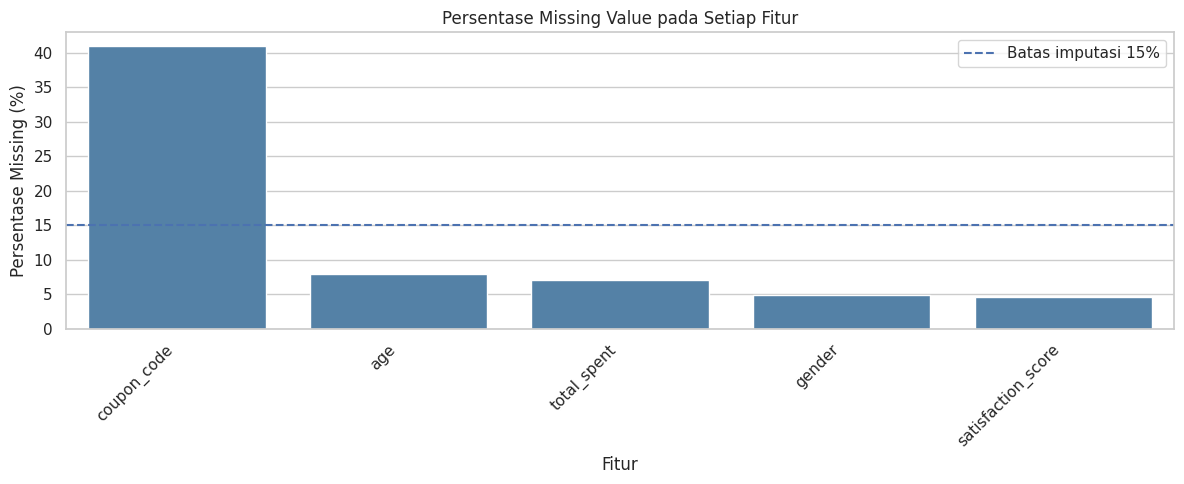

In [6]:
# ============================================================
# VISUALISASI MISSING VALUE
# ============================================================

missing_to_plot = missing_summary[
    missing_summary["Persentase Missing (%)"] > 0
]

plt.figure(figsize=(12, 5))
sns.barplot(
    data=missing_to_plot.reset_index(),
    x="index",
    y="Persentase Missing (%)",
    color="steelblue"
)
plt.axhline(
    MISSING_THRESHOLD,
    linestyle="--",
    label="Batas imputasi 15%"
)
plt.title("Persentase Missing Value pada Setiap Fitur")
plt.xlabel("Fitur")
plt.ylabel("Persentase Missing (%)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 1.3 Distribusi Target Sebelum SMOTE

,Churn,Jumlah,Persentase (%)
0,0,12702,84.68
1,1,2298,15.32


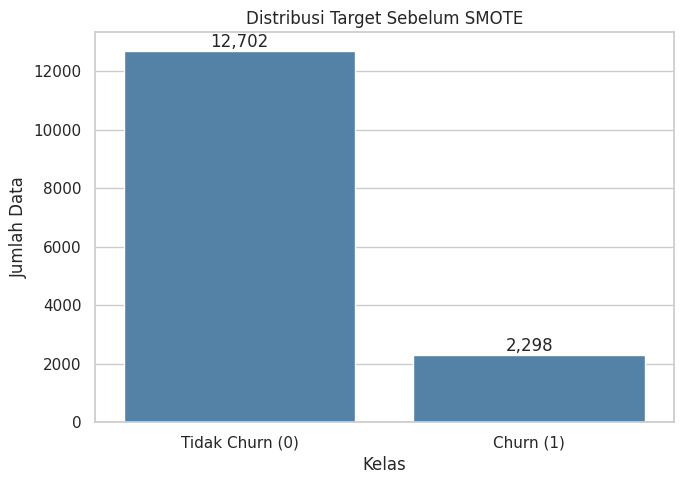

In [7]:
# ============================================================
# DISTRIBUSI TARGET
# ============================================================

target_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .rename_axis("Churn")
    .reset_index(name="Jumlah")
)

target_distribution["Persentase (%)"] = (
    target_distribution["Jumlah"]
    / target_distribution["Jumlah"].sum()
    * 100
)

display(target_distribution)

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x=TARGET_COLUMN, color="steelblue")

plt.title("Distribusi Target Sebelum SMOTE")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.xticks([0, 1], ["Tidak Churn (0)", "Churn (1)"])

for bar in ax.patches:
    value = int(bar.get_height())
    ax.annotate(
        f"{value:,}",
        (bar.get_x() + bar.get_width() / 2, value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 1.4 Feature Engineering Awal

Kolom sumber yang tidak dapat langsung digunakan model tidak langsung dibuang informasinya:

- `coupon_code` diubah menjadi `has_coupon_code`.
- `signup_date` dan `last_purchase_date` diubah menjadi `customer_tenure_days` dan `days_since_last_purchase`.
- Kolom tanggal asli dan kode kupon asli kemudian dihapus karena informasinya sudah diwakili fitur baru.

In [8]:
# ============================================================
# FUNGSI FEATURE ENGINEERING
# ============================================================

def create_engineered_features(data, fixed_reference_date=None):
    engineered = data.copy()

    if "coupon_code" in engineered.columns:
        engineered["has_coupon_code"] = (
            engineered["coupon_code"].notna().astype(int)
        )
        engineered = engineered.drop(columns=["coupon_code"])

    for date_column in ["signup_date", "last_purchase_date"]:
        if date_column in engineered.columns:
            engineered[date_column] = pd.to_datetime(
                engineered[date_column],
                errors="coerce"
            )

    reference_date_used = fixed_reference_date

    if (
        "signup_date" in engineered.columns
        and "last_purchase_date" in engineered.columns
    ):
        if reference_date_used is None:
            reference_date_used = engineered["last_purchase_date"].max()

        # Dataset memiliki beberapa urutan tanggal yang tidak konsisten.
        # Selisih absolut digunakan agar durasi tetap non-negatif.
        engineered["customer_tenure_days"] = (
            engineered["last_purchase_date"]
            - engineered["signup_date"]
        ).dt.days.abs()

        engineered["days_since_last_purchase"] = (
            reference_date_used
            - engineered["last_purchase_date"]
        ).dt.days

        engineered = engineered.drop(
            columns=["signup_date", "last_purchase_date"]
        )

    return engineered, reference_date_used


df_engineered, reference_date = create_engineered_features(df)

print("Feature engineering selesai.")
print("Tanggal referensi:", reference_date)
display(df_engineered.head())

Feature engineering selesai.
Tanggal referensi: 2025-03-10 00:00:00


,customer_id,gender,age,country,city,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn,has_coupon_code,customer_tenure_days,days_since_last_purchase
0,10001,Male,52.0,India,Berlin,Email,Tablet,Annual,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,0,0,0,3,UPI,3.0,10,27.56,915.310827,14,0,1,966,69
1,10002,NaN,35.0,Germany,Mumbai,Organic,Desktop,Monthly,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,1,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0,1,40,307
2,10003,Female,27.0,Germany,London,Email,Mobile,Annual,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,0,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0,0,249,316
3,10004,Female,36.0,India,Mumbai,Facebook Ads,Tablet,Annual,1,16,9.642654,2.949531,0.58,0.37,445.429636,71.712192,0,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0,0,253,660
4,10005,Male,29.0,USA,Hamburg,Referral,Mobile,Monthly,0,12,7.791291,2.405539,0.05,0.16,686.286022,44.990246,1,2,1,4,BKash,3.0,1,12.39,87.680409,11,0,0,261,337


## 1.5 Visualisasi Outlier pada Tahap EDA

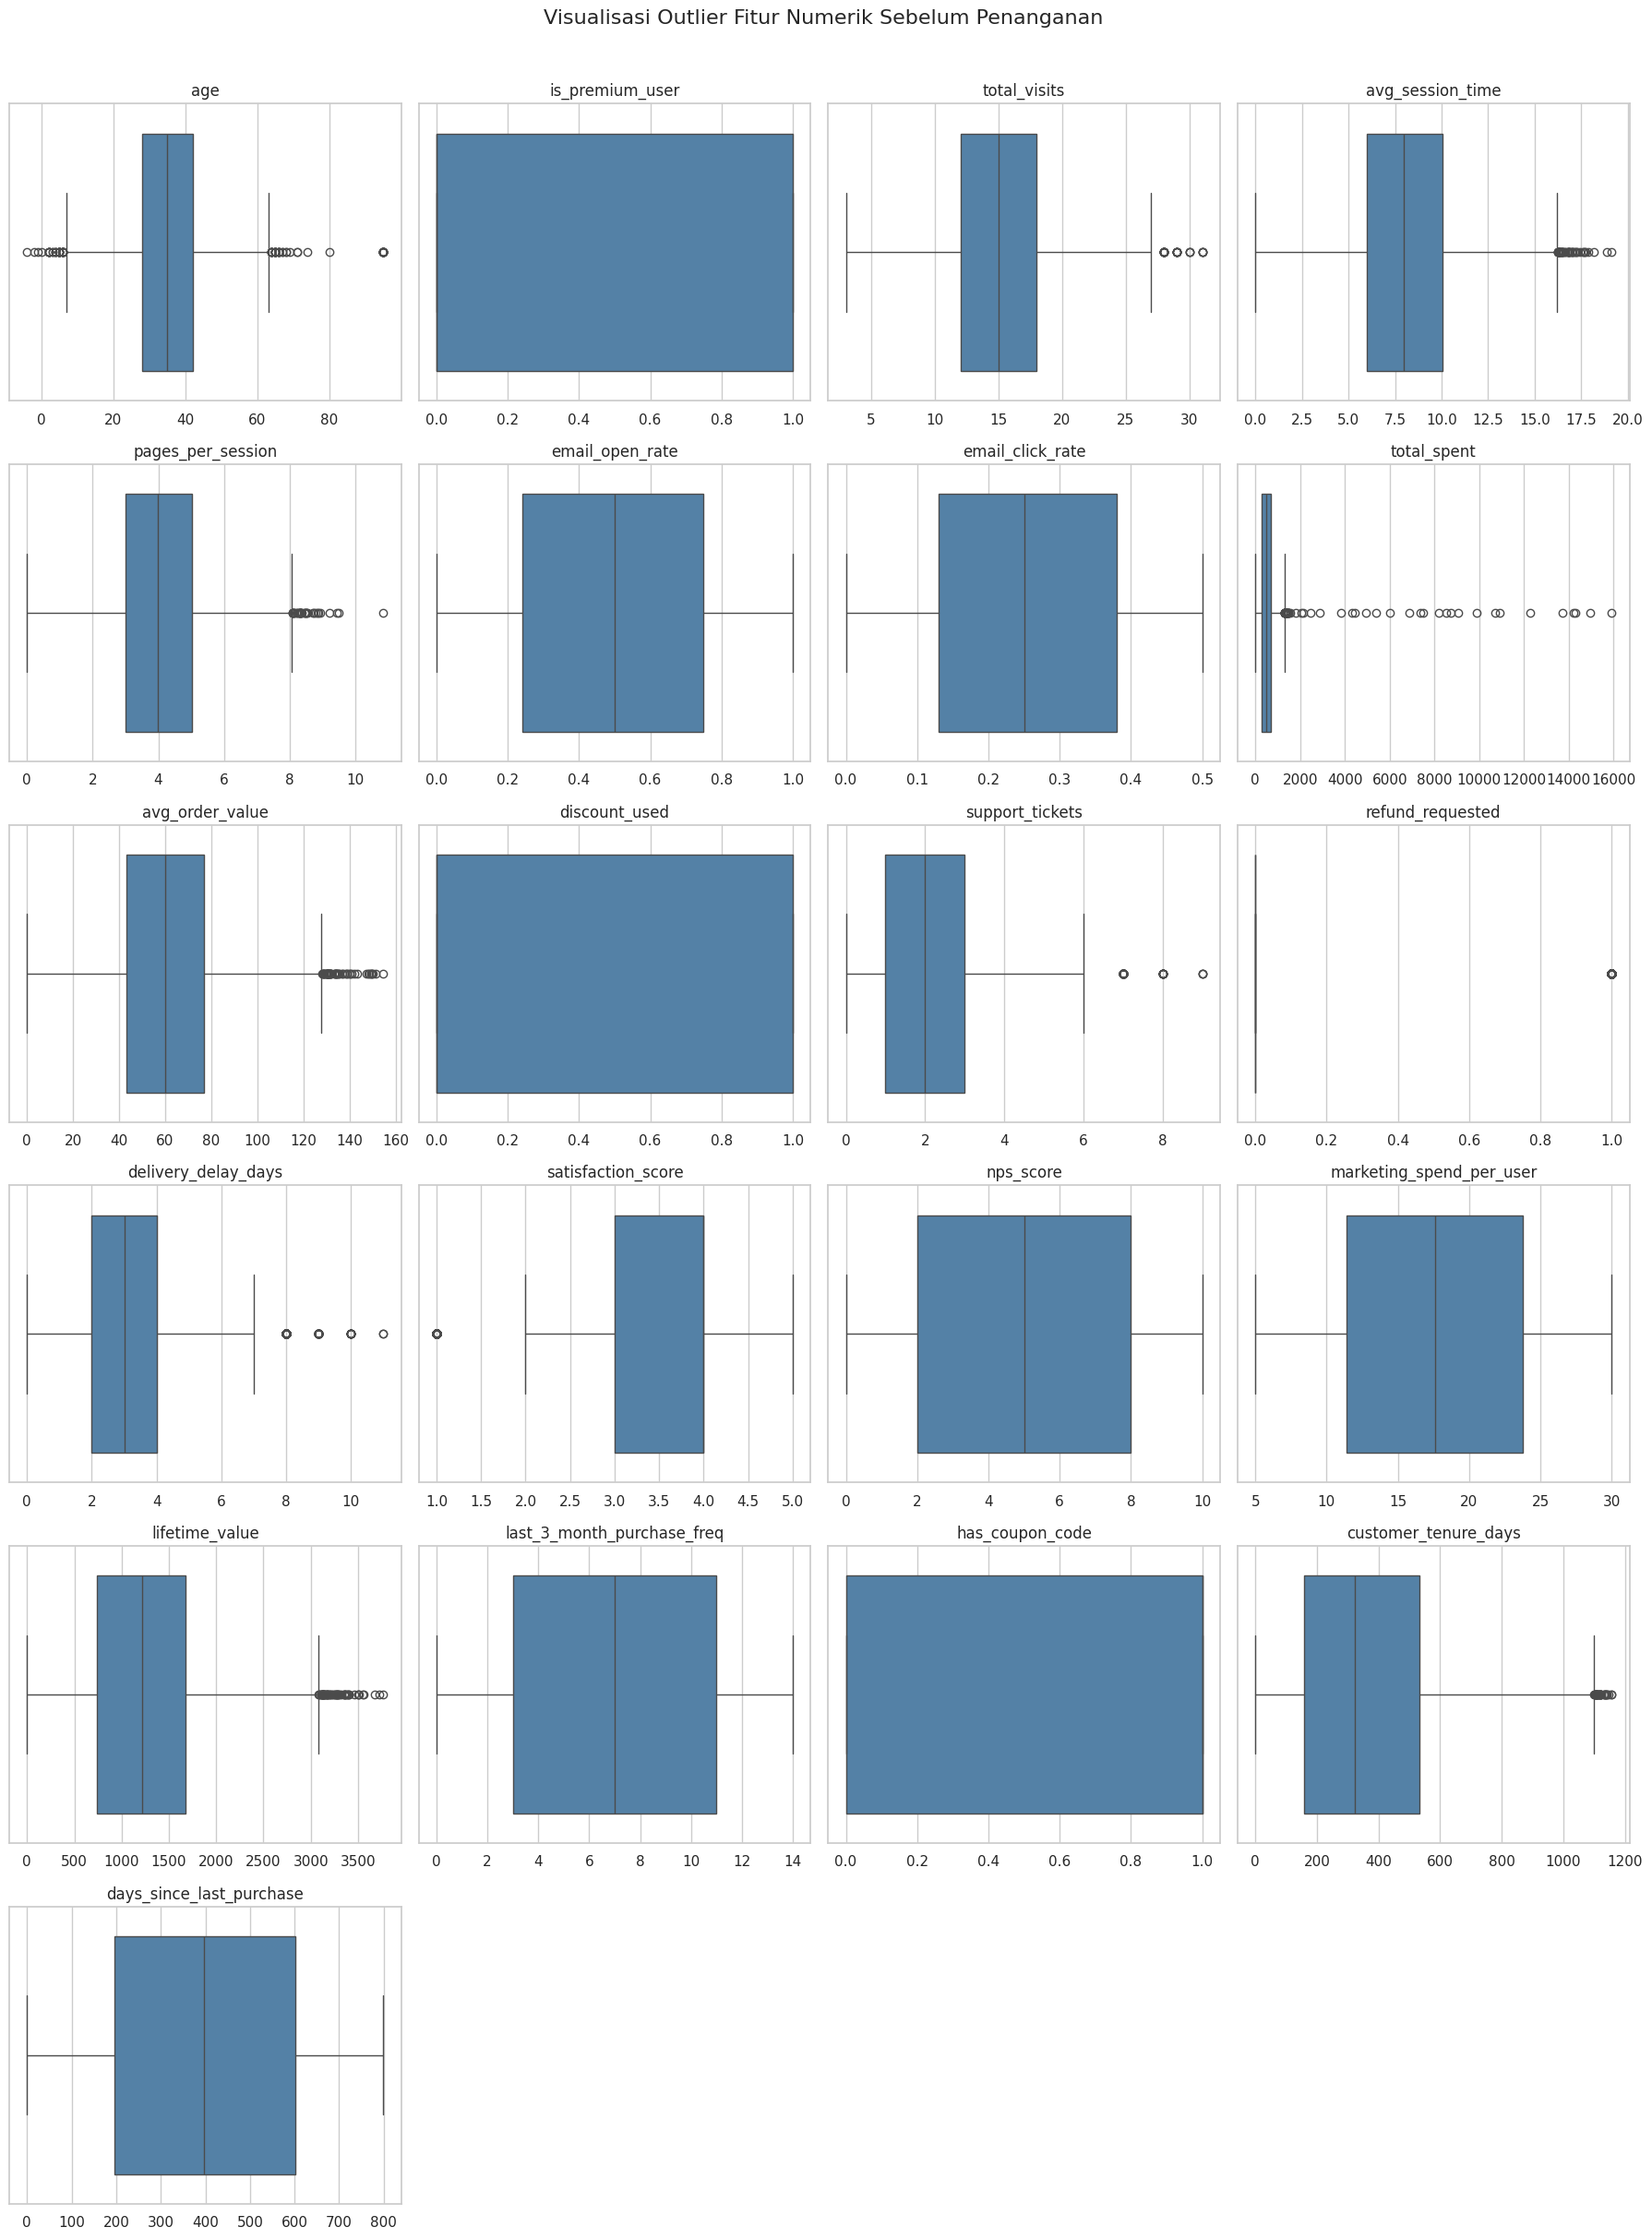

In [9]:
# ============================================================
# VISUALISASI BOXPLOT FITUR NUMERIK
# ============================================================

eda_numeric_columns = (
    df_engineered
    .drop(columns=[TARGET_COLUMN], errors="ignore")
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

# ID ditampilkan pada tabel pengaruh, tetapi tidak perlu divisualisasikan
# sebagai boxplot karena nilainya hanya identitas berurutan.
boxplot_columns = [
    column
    for column in eda_numeric_columns
    if column != "customer_id"
]

n_columns = 4
n_rows = ceil(len(boxplot_columns) / n_columns)

fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(18, 4 * n_rows)
)
axes = np.array(axes).reshape(-1)

for axis, column in zip(axes, boxplot_columns):
    sns.boxplot(x=df_engineered[column], ax=axis, color="steelblue")
    axis.set_title(column)
    axis.set_xlabel("")

for axis in axes[len(boxplot_columns):]:
    axis.set_visible(False)

fig.suptitle(
    "Visualisasi Outlier Fitur Numerik Sebelum Penanganan",
    fontsize=16,
    y=1.01
)
plt.tight_layout()
plt.show()

,Fitur,Jumlah Outlier,Persentase Outlier (%)
11,refund_requested,2215,14.766667
13,satisfaction_score,753,5.266471
12,delivery_delay_days,184,1.226667
0,age,89,0.644928
10,support_tickets,79,0.526667
7,total_spent,78,0.559140
16,lifetime_value,56,0.373333
8,avg_order_value,54,0.360000
3,avg_session_time,45,0.300000
2,total_visits,39,0.260000


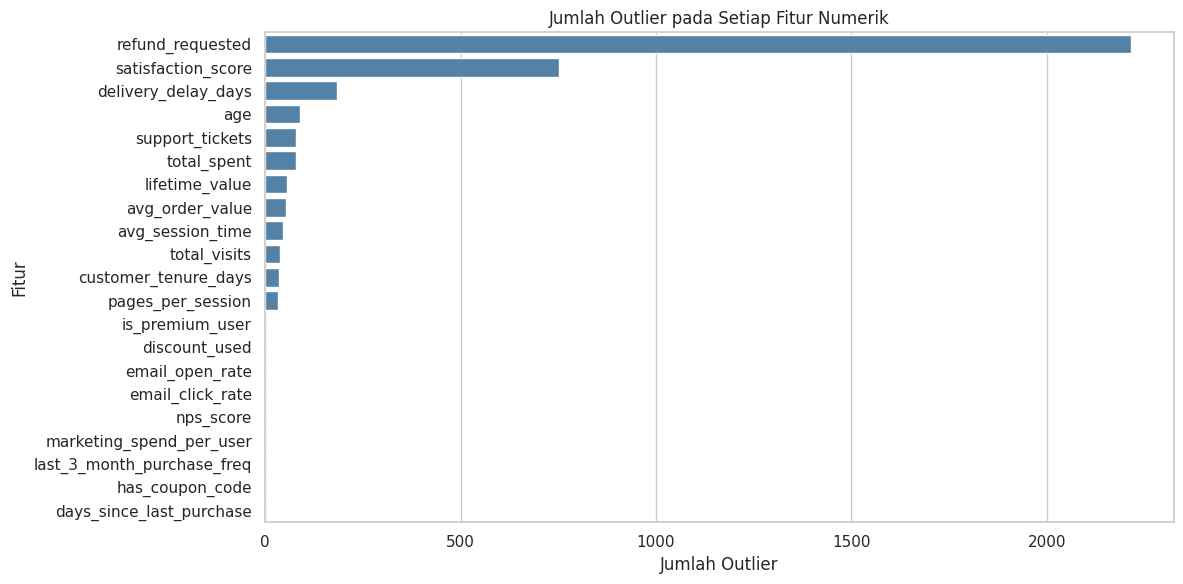

In [10]:
# ============================================================
# MENGHITUNG JUMLAH OUTLIER DENGAN METODE IQR
# ============================================================

outlier_records = []

for column in boxplot_columns:
    series = df_engineered[column].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outlier_count = (
        (series < lower_bound)
        | (series > upper_bound)
    ).sum()

    outlier_records.append({
        "Fitur": column,
        "Jumlah Outlier": int(outlier_count),
        "Persentase Outlier (%)": (
            outlier_count / len(series) * 100
            if len(series) > 0
            else 0
        )
    })

outlier_summary = (
    pd.DataFrame(outlier_records)
    .sort_values("Jumlah Outlier", ascending=False)
)

display(outlier_summary)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=outlier_summary,
    x="Jumlah Outlier",
    y="Fitur",
    color="steelblue"
)
plt.title("Jumlah Outlier pada Setiap Fitur Numerik")
plt.xlabel("Jumlah Outlier")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

## 1.6 Imputasi untuk EDA dan Encoding Seluruh Kategori

Sebelum heatmap:

- Missing numerik di bawah 15% diisi dengan **mean** jika distribusinya relatif simetris (`|skewness| ≤ 1`) dan **median** jika distribusinya miring atau memiliki pengaruh nilai ekstrem.
- Missing kategorikal di bawah 15% diisi dengan **modus** karena mean dan median tidak dapat digunakan pada data teks.
- Seluruh fitur kategorikal kemudian diubah dengan One-Hot Encoding agar setiap kategori ikut masuk dalam analisis korelasi.

In [11]:
# ============================================================
# IMPUTASI EDA SEBELUM ENCODING
# ============================================================

df_eda_ready = df_engineered.copy()

eda_imputation_records = []

numeric_columns_eda = (
    df_eda_ready
    .drop(columns=[TARGET_COLUMN], errors="ignore")
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_columns_eda = (
    df_eda_ready
    .drop(columns=[TARGET_COLUMN], errors="ignore")
    .select_dtypes(include=["object", "category", "bool"])
    .columns
    .tolist()
)

for column in numeric_columns_eda:
    missing_pct = df_eda_ready[column].isna().mean() * 100

    if 0 < missing_pct < MISSING_THRESHOLD:
        skewness = df_eda_ready[column].dropna().skew()

        if abs(skewness) <= 1:
            strategy = "mean"
            fill_value = df_eda_ready[column].mean()
        else:
            strategy = "median"
            fill_value = df_eda_ready[column].median()

        df_eda_ready[column] = df_eda_ready[column].fillna(fill_value)

        eda_imputation_records.append({
            "Fitur": column,
            "Tipe": "Numerik",
            "Missing (%)": missing_pct,
            "Skewness": skewness,
            "Strategi": strategy,
            "Nilai Pengganti": fill_value
        })

for column in categorical_columns_eda:
    missing_pct = df_eda_ready[column].isna().mean() * 100

    if 0 < missing_pct < MISSING_THRESHOLD:
        mode_value = df_eda_ready[column].mode(dropna=True)

        if mode_value.empty:
            fill_value = "Unknown"
        else:
            fill_value = mode_value.iloc[0]

        df_eda_ready[column] = df_eda_ready[column].fillna(fill_value)

        eda_imputation_records.append({
            "Fitur": column,
            "Tipe": "Kategorikal",
            "Missing (%)": missing_pct,
            "Skewness": np.nan,
            "Strategi": "modus",
            "Nilai Pengganti": fill_value
        })
    elif missing_pct >= MISSING_THRESHOLD:
        # Pengamanan jika masih terdapat fitur kategorikal dengan missing >= 15%.
        df_eda_ready[column] = df_eda_ready[column].fillna("Missing")

        eda_imputation_records.append({
            "Fitur": column,
            "Tipe": "Kategorikal",
            "Missing (%)": missing_pct,
            "Skewness": np.nan,
            "Strategi": "kategori Missing",
            "Nilai Pengganti": "Missing"
        })

eda_imputation_summary = pd.DataFrame(eda_imputation_records)

print("Ringkasan imputasi yang digunakan sebelum heatmap:")
display(eda_imputation_summary)

Ringkasan imputasi yang digunakan sebelum heatmap:


,Fitur,Tipe,Missing (%),Skewness,Strategi,Nilai Pengganti
0,age,Numerik,8.00,0.397115,mean,35.203913
1,total_spent,Numerik,7.00,15.755867,median,498.843859
2,satisfaction_score,Numerik,4.68,-0.584436,mean,3.588754
3,gender,Kategorikal,4.92,NaN,modus,Male


Fitur numerik kontinu yang masuk heatmap:
- age
- avg_session_time
- pages_per_session
- email_open_rate
- email_click_rate
- total_spent
- avg_order_value
- marketing_spend_per_user
- lifetime_value
- customer_tenure_days
- days_since_last_purchase

Jumlah kategori hasil One-Hot Encoding: 30
Jumlah seluruh fitur pada heatmap: 41


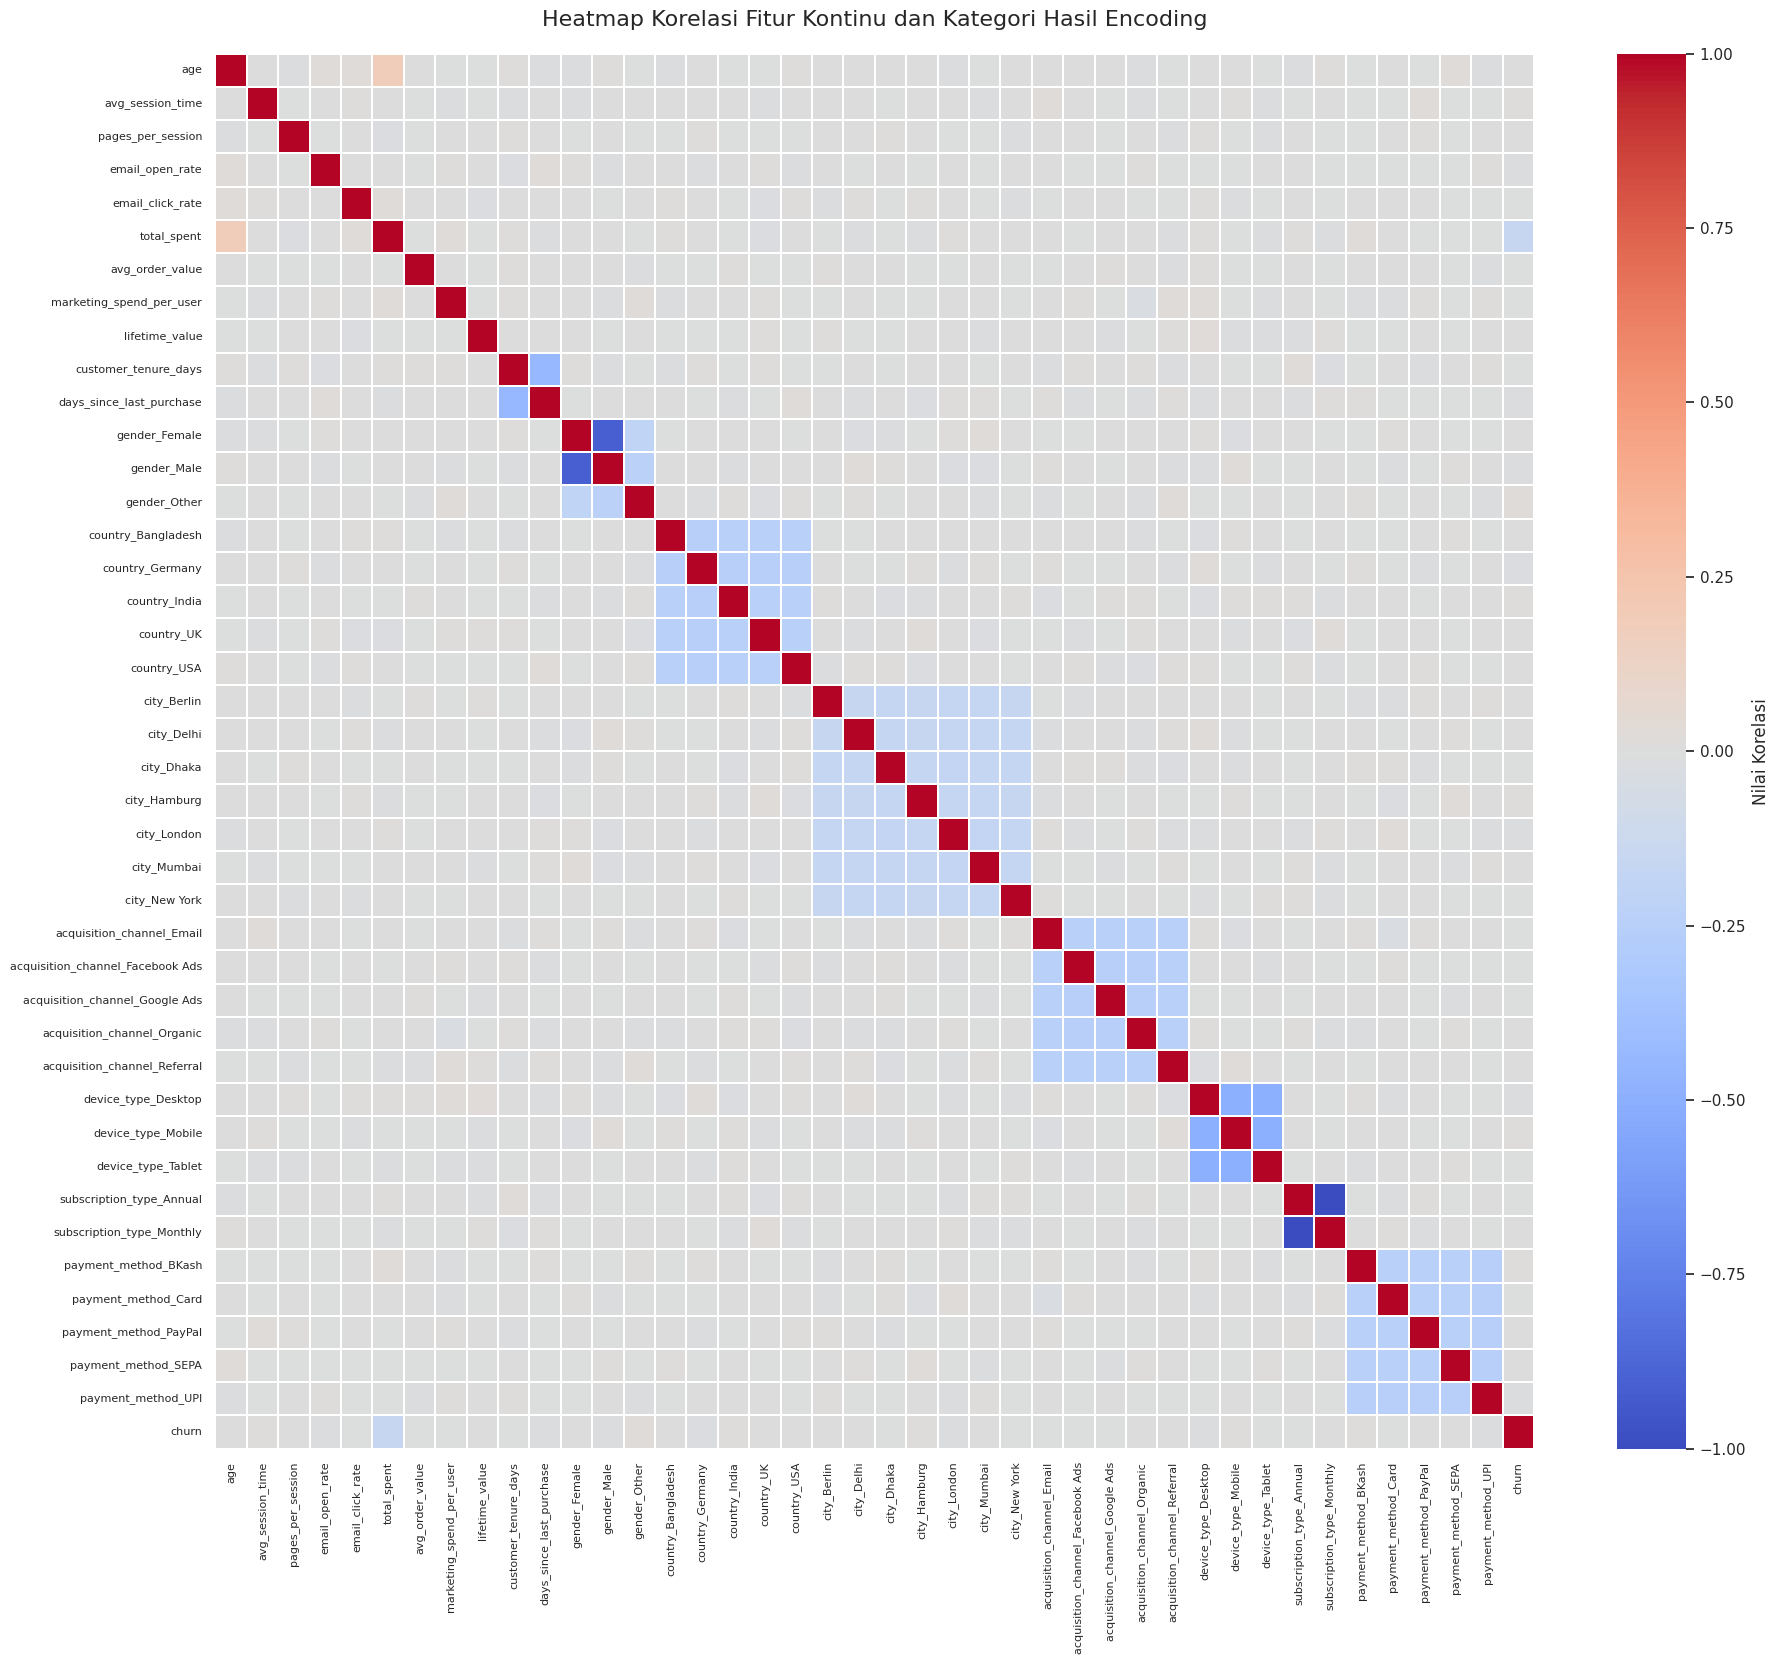

In [12]:
# ============================================================
# HEATMAP FITUR KONTINU DAN KATEGORI HASIL ENCODING
# ============================================================

# One-Hot Encoding seluruh fitur kategorikal
df_eda_encoded = pd.get_dummies(
    df_eda_ready,
    columns=categorical_columns_eda,
    drop_first=False,
    dtype=int
)

# ============================================================
# KORELASI SELURUH FITUR
# Tetap digunakan oleh cell berikutnya untuk:
# 1. Mengukur pengaruh seluruh fitur terhadap churn
# 2. Menentukan tiga fitur low-impact
# ============================================================

corr_matrix_encoded = df_eda_encoded.corr(
    numeric_only=True
)

# ============================================================
# FITUR NUMERIK KONTINU YANG DITAMPILKAN PADA HEATMAP
# ============================================================

continuous_numeric_candidates = [
    "age",
    "avg_session_time",
    "pages_per_session",
    "email_open_rate",
    "email_click_rate",
    "total_spent",
    "avg_order_value",
    "marketing_spend_per_user",
    "lifetime_value",
    "customer_tenure_days",
    "days_since_last_purchase"
]

# Hanya mengambil fitur yang benar-benar tersedia dalam dataset
continuous_numeric_columns = [
    column
    for column in continuous_numeric_candidates
    if column in df_eda_encoded.columns
]

# ============================================================
# MENGAMBIL SELURUH KOLOM HASIL ONE-HOT ENCODING
# ============================================================

encoded_categorical_columns = []

for categorical_column in categorical_columns_eda:
    prefix = f"{categorical_column}_"

    matching_columns = [
        column
        for column in df_eda_encoded.columns
        if column.startswith(prefix)
    ]

    encoded_categorical_columns.extend(
        matching_columns
    )

# Menghilangkan kemungkinan nama kolom yang terduplikasi
encoded_categorical_columns = list(
    dict.fromkeys(encoded_categorical_columns)
)

# ============================================================
# KOLOM YANG MASUK KE VISUALISASI HEATMAP
# ============================================================

heatmap_columns = (
    continuous_numeric_columns
    + encoded_categorical_columns
    + [TARGET_COLUMN]
)

# Menghilangkan duplikasi nama kolom
heatmap_columns = list(
    dict.fromkeys(heatmap_columns)
)

heatmap_corr_matrix = (
    df_eda_encoded[heatmap_columns]
    .corr()
)

print("Fitur numerik kontinu yang masuk heatmap:")
for column in continuous_numeric_columns:
    print("-", column)

print(
    "\nJumlah kategori hasil One-Hot Encoding:",
    len(encoded_categorical_columns)
)

print(
    "Jumlah seluruh fitur pada heatmap:",
    len(heatmap_columns) - 1
)

# ============================================================
# VISUALISASI HEATMAP
# ============================================================

figure_width = max(
    16,
    len(heatmap_columns) * 0.45
)

figure_height = max(
    13,
    len(heatmap_columns) * 0.40
)

plt.figure(
    figsize=(figure_width, figure_height)
)

sns.heatmap(
    heatmap_corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={
        "label": "Nilai Korelasi"
    }
)

plt.title(
    "Heatmap Korelasi Fitur Kontinu dan Kategori Hasil Encoding",
    fontsize=16,
    pad=20
)

plt.xticks(
    rotation=90,
    fontsize=8
)

plt.yticks(
    rotation=0,
    fontsize=8
)

plt.tight_layout()
plt.show()

## 1.7 Pengaruh Seluruh Fitur dan Pemilihan Tiga Fitur Terendah

Pengaruh seluruh fitur, termasuk seluruh kategori hasil encoding:


,Fitur Hasil Encoding,Korelasi terhadap Churn,Absolut Korelasi
0,satisfaction_score,-0.298301,0.298301
1,total_spent,-0.158525,0.158525
2,support_tickets,0.127910,0.127910
3,gender_Other,0.019637,0.019637
4,country_Germany,-0.019553,0.019553
5,has_coupon_code,0.013770,0.013770
6,total_visits,0.013212,0.013212
7,gender_Male,-0.012795,0.012795
8,customer_id,0.012208,0.012208
9,avg_session_time,0.012198,0.012198


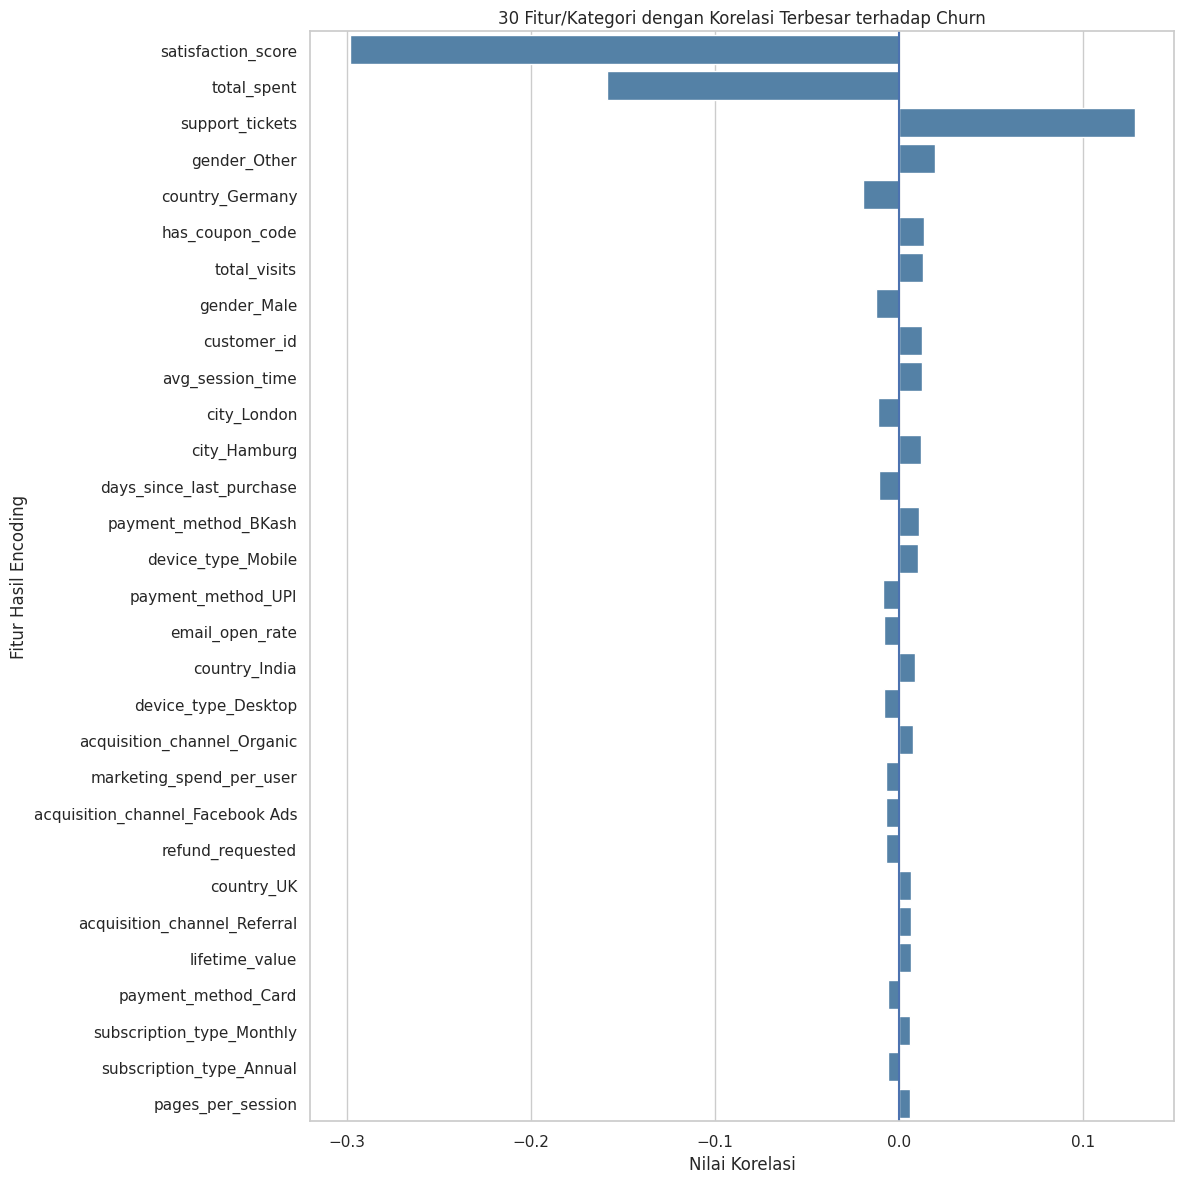

In [13]:
# ============================================================
# KORELASI SETIAP FITUR HASIL ENCODING TERHADAP CHURN
# ============================================================

encoded_churn_correlation = (
    corr_matrix_encoded[TARGET_COLUMN]
    .drop(labels=[TARGET_COLUMN])
    .fillna(0)
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
)

encoded_churn_correlation_df = pd.DataFrame({
    "Fitur Hasil Encoding": encoded_churn_correlation.index,
    "Korelasi terhadap Churn": encoded_churn_correlation.values,
    "Absolut Korelasi": encoded_churn_correlation.abs().values
})

print("Pengaruh seluruh fitur, termasuk seluruh kategori hasil encoding:")
display(encoded_churn_correlation_df)

plt.figure(figsize=(12, 12))
sns.barplot(
    data=encoded_churn_correlation_df.head(30),
    x="Korelasi terhadap Churn",
    y="Fitur Hasil Encoding",
    color="steelblue"
)
plt.axvline(0)
plt.title("30 Fitur/Kategori dengan Korelasi Terbesar terhadap Churn")
plt.xlabel("Nilai Korelasi")
plt.ylabel("Fitur Hasil Encoding")
plt.tight_layout()
plt.show()

Peringkat pengaruh fitur asli dari yang terendah:


,Fitur Asli,Jumlah Kolom Hasil Encoding,Korelasi Absolut Maksimum,Korelasi Absolut Rata-rata
0,discount_used,1,0.000265,0.000265
1,avg_order_value,1,0.001480,0.001480
2,last_3_month_purchase_freq,1,0.001590,0.001590
3,delivery_delay_days,1,0.001603,0.001603
4,email_click_rate,1,0.001752,0.001752
5,customer_tenure_days,1,0.002555,0.002555
6,age,1,0.004316,0.004316
7,is_premium_user,1,0.005496,0.005496
8,nps_score,1,0.005749,0.005749
9,pages_per_session,1,0.005871,0.005871



Tepat tiga fitur yang akan dihapus karena pengaruhnya paling rendah:
- customer_id
- discount_used
- avg_order_value


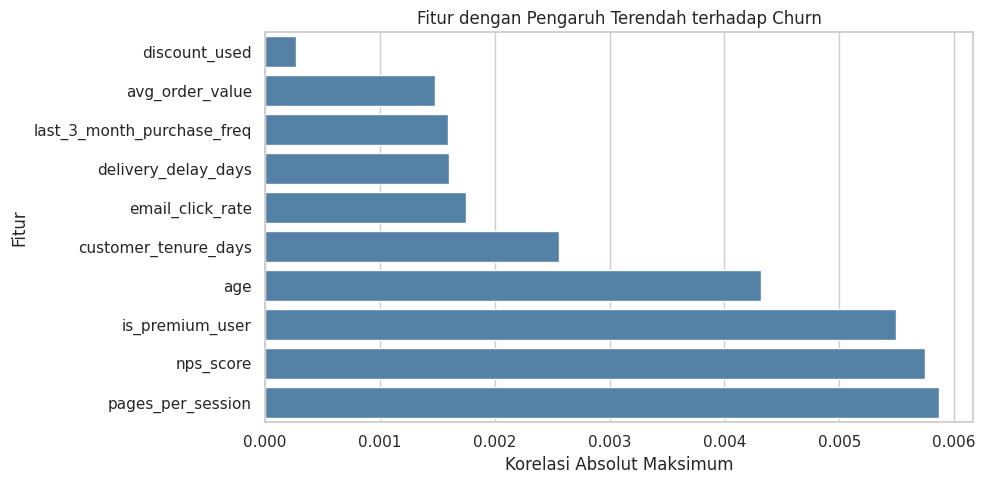

In [14]:
# ============================================================
# AGREGASI PENGARUH KE FITUR ASLI
# DAN PENENTUAN TEPAT TIGA FITUR LOW-IMPACT
# ============================================================

original_feature_columns = [
    column
    for column in df_eda_ready.columns
    if column != TARGET_COLUMN
]

feature_influence_records = []

for original_feature in original_feature_columns:
    related_encoded_columns = [
        encoded_feature
        for encoded_feature in encoded_churn_correlation.index
        if (
            encoded_feature == original_feature
            or encoded_feature.startswith(f"{original_feature}_")
        )
    ]

    if len(related_encoded_columns) == 0:
        continue

    absolute_correlations = (
        encoded_churn_correlation
        .loc[related_encoded_columns]
        .abs()
    )

    feature_influence_records.append({
        "Fitur Asli": original_feature,
        "Jumlah Kolom Hasil Encoding": len(related_encoded_columns),
        "Korelasi Absolut Maksimum": absolute_correlations.max(),
        "Korelasi Absolut Rata-rata": absolute_correlations.mean()
    })

feature_influence_df = (
    pd.DataFrame(feature_influence_records)
    .sort_values(
        by=[
            "Korelasi Absolut Maksimum",
            "Korelasi Absolut Rata-rata"
        ],
        ascending=True
    )
    .reset_index(drop=True)
)

print("Peringkat pengaruh fitur asli dari yang terendah:")
display(feature_influence_df)

# customer_id wajib menjadi salah satu kandidat low-impact karena hanya ID.
# Dua fitur lainnya dipilih secara otomatis dari korelasi terendah.
if "customer_id" in feature_influence_df["Fitur Asli"].values:
    remaining_low_features = (
        feature_influence_df[
            feature_influence_df["Fitur Asli"] != "customer_id"
        ]
        .head(LOW_IMPACT_FEATURE_COUNT - 1)["Fitur Asli"]
        .tolist()
    )

    low_impact_features = ["customer_id"] + remaining_low_features
else:
    low_impact_features = (
        feature_influence_df
        .head(LOW_IMPACT_FEATURE_COUNT)["Fitur Asli"]
        .tolist()
    )

if len(low_impact_features) != LOW_IMPACT_FEATURE_COUNT:
    raise ValueError(
        "Jumlah fitur low-impact yang dipilih tidak sama dengan tiga."
    )

print("\nTepat tiga fitur yang akan dihapus karena pengaruhnya paling rendah:")
for feature in low_impact_features:
    print("-", feature)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_influence_df.head(10),
    x="Korelasi Absolut Maksimum",
    y="Fitur Asli",
    color="steelblue"
)
plt.title("Fitur dengan Pengaruh Terendah terhadap Churn")
plt.xlabel("Korelasi Absolut Maksimum")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

## Kesimpulan EDA

Seluruh kategori sudah diubah ke bentuk numerik sebelum heatmap. Outlier juga telah divisualisasikan, missing value telah dianalisis berdasarkan ambang 15%, dan tepat tiga fitur dengan pengaruh terendah telah ditentukan untuk dihapus pada tahap modeling.

# Poin Penugasan 2 — Modeling

## Fungsi Pembagian Data, SMOTE, dan Evaluasi

In [15]:
# ============================================================
# FUNGSI PEMBAGIAN TRAIN, VALIDATION, DAN TEST
# ============================================================

def stratified_train_val_test_split(
    X,
    y,
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=RANDOM_STATE
):
    total = train_size + val_size + test_size

    if not np.isclose(total, 1.0):
        raise ValueError("Jumlah proporsi train, validation, dan test harus 1.")

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    relative_val_size = val_size / (train_size + val_size)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=relative_val_size,
        random_state=random_state,
        stratify=y_train_val
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


# ============================================================
# FUNGSI SMOTE
# ============================================================

def apply_smote_to_split(X_data, y_data, random_state=RANDOM_STATE):
    smote = SMOTE(
        random_state=random_state,
        k_neighbors=5
    )

    X_resampled, y_resampled = smote.fit_resample(X_data, y_data)

    X_resampled = pd.DataFrame(
        X_resampled,
        columns=X_data.columns
    )

    y_resampled = pd.Series(
        y_resampled,
        name=TARGET_COLUMN
    )

    return X_resampled, y_resampled


# ============================================================
# FUNGSI EVALUASI MODEL
# ============================================================

evaluation_results = []

def evaluate_classification_model(
    model_name,
    scenario_name,
    dataset_name,
    y_true,
    y_pred,
    save_result=True
):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    result = {
        "Skenario": scenario_name,
        "Dataset Evaluasi": dataset_name,
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

    if save_result:
        evaluation_results.append(result)

    print("=" * 75)
    print(f"{scenario_name} — {model_name}")
    print(f"Dataset evaluasi: {dataset_name}")
    print("=" * 75)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-Score :", round(f1, 4))

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    matrix = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Tidak Churn (0)", "Churn (1)"],
        yticklabels=["Tidak Churn (0)", "Churn (1)"]
    )
    plt.title(
        f"Confusion Matrix — {model_name}\n{dataset_name}"
    )
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.tight_layout()
    plt.show()

    return result

# 2.1 Direct Modeling dengan SMOTE

Direct modeling tetap digunakan sebagai baseline. Pada skenario ini hanya fitur numerik yang digunakan dan belum dilakukan encoding, scaling, maupun outlier capping. Imputasi hanya dilakukan agar missing value tidak menyebabkan error. SMOTE diterapkan setelah data dibagi.

In [16]:
# ============================================================
# MENYIAPKAN DATA DIRECT MODELING
# ============================================================

df_model_base = df_engineered.drop(
    columns=low_impact_features,
    errors="ignore"
).copy()

X_direct = (
    df_model_base
    .drop(columns=[TARGET_COLUMN])
    .select_dtypes(include=np.number)
    .copy()
)

y_direct = df_model_base[TARGET_COLUMN].copy()

(
    X_train_direct,
    X_val_direct,
    X_test_direct,
    y_train_direct,
    y_val_direct,
    y_test_direct
) = stratified_train_val_test_split(
    X_direct,
    y_direct
)

print("Pembagian direct modeling selesai.")
print("Train     :", X_train_direct.shape)
print("Validation:", X_val_direct.shape)
print("Test      :", X_test_direct.shape)

Pembagian direct modeling selesai.
Train     : (10500, 19)
Validation: (2250, 19)
Test      : (2250, 19)


In [17]:
# ============================================================
# IMPUTASI DIRECT MODELING BERDASARKAN DATA TRAIN
# ============================================================

direct_imputation_summary = []

for column in X_train_direct.columns:
    missing_pct = X_train_direct[column].isna().mean() * 100

    if missing_pct == 0:
        continue

    if missing_pct >= MISSING_THRESHOLD:
        raise ValueError(
            f"Fitur numerik {column} memiliki missing "
            f"{missing_pct:.2f}% dan perlu penanganan khusus."
        )

    skewness = X_train_direct[column].dropna().skew()

    if abs(skewness) <= 1:
        strategy = "mean"
        fill_value = X_train_direct[column].mean()
    else:
        strategy = "median"
        fill_value = X_train_direct[column].median()

    X_train_direct[column] = X_train_direct[column].fillna(fill_value)
    X_val_direct[column] = X_val_direct[column].fillna(fill_value)
    X_test_direct[column] = X_test_direct[column].fillna(fill_value)

    direct_imputation_summary.append({
        "Fitur": column,
        "Missing Train (%)": missing_pct,
        "Skewness": skewness,
        "Strategi": strategy,
        "Nilai Pengganti": fill_value
    })

display(pd.DataFrame(direct_imputation_summary))

,Fitur,Missing Train (%),Skewness,Strategi,Nilai Pengganti
0,age,7.942857,0.348701,mean,35.226981
1,total_spent,6.990476,16.571264,median,501.399679
2,satisfaction_score,4.609524,-0.578857,mean,3.588758


In [18]:
# ============================================================
# SMOTE DIRECT: HANYA TRAIN DAN VALIDATION
# ============================================================

X_train_direct_smote, y_train_direct_smote = apply_smote_to_split(
    X_train_direct.reset_index(drop=True),
    y_train_direct.reset_index(drop=True)
)

X_val_direct_smote, y_val_direct_smote = apply_smote_to_split(
    X_val_direct.reset_index(drop=True),
    y_val_direct.reset_index(drop=True)
)

print("Distribusi train setelah SMOTE:")
display(y_train_direct_smote.value_counts().sort_index())

print("\nDistribusi validation setelah SMOTE:")
display(y_val_direct_smote.value_counts().sort_index())

print("\nDistribusi test tetap asli:")
display(y_test_direct.value_counts().sort_index())

Distribusi train setelah SMOTE:


,count
churn,
0,8892
1,8892



Distribusi validation setelah SMOTE:


,count
churn,
0,1905
1,1905



Distribusi test tetap asli:


,count
churn,
0,1905
1,345


Direct Modeling + SMOTE — Logistic Regression
Dataset evaluasi: Validation setelah SMOTE
Accuracy : 0.7612
Precision: 0.7499
Recall   : 0.7837
F1-Score : 0.7664

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.74      0.76      1905
           1       0.75      0.78      0.77      1905

    accuracy                           0.76      3810
   macro avg       0.76      0.76      0.76      3810
weighted avg       0.76      0.76      0.76      3810



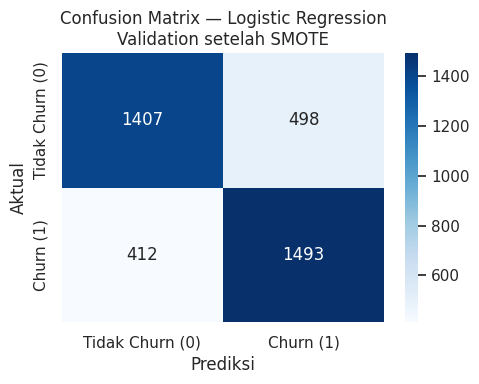

Direct Modeling + SMOTE — Random Forest
Dataset evaluasi: Validation setelah SMOTE
Accuracy : 0.8793
Precision: 0.8622
Recall   : 0.9029
F1-Score : 0.8821

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      1905
           1       0.86      0.90      0.88      1905

    accuracy                           0.88      3810
   macro avg       0.88      0.88      0.88      3810
weighted avg       0.88      0.88      0.88      3810



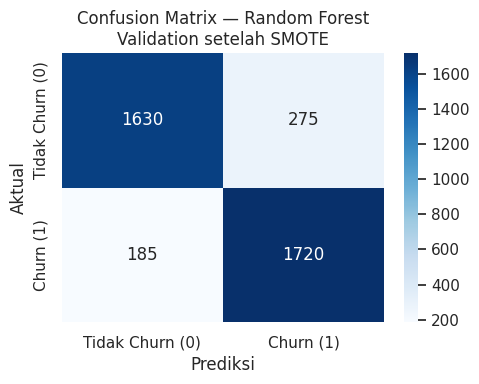

Direct Modeling + SMOTE — Voting Classifier
Dataset evaluasi: Validation setelah SMOTE
Accuracy : 0.7782
Precision: 0.7642
Recall   : 0.8047
F1-Score : 0.7839

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77      1905
           1       0.76      0.80      0.78      1905

    accuracy                           0.78      3810
   macro avg       0.78      0.78      0.78      3810
weighted avg       0.78      0.78      0.78      3810



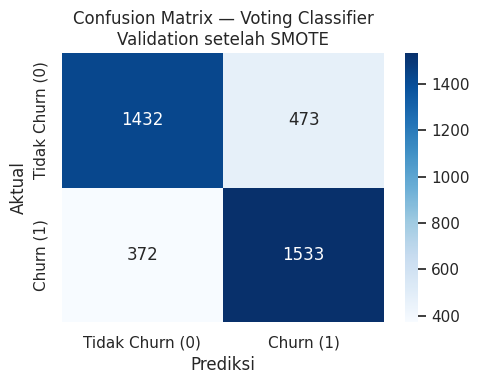

In [19]:
# ============================================================
# TIGA MODEL DIRECT MODELING
# ============================================================

direct_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Voting Classifier": VotingClassifier(
        estimators=[
            (
                "lr",
                LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE
                )
            ),
            (
                "knn",
                KNeighborsClassifier(n_neighbors=5)
            ),
            (
                "nb",
                GaussianNB()
            )
        ],
        voting="soft"
    )
}

for model_name, model in direct_models.items():
    model.fit(
        X_train_direct_smote,
        y_train_direct_smote
    )

    direct_prediction = model.predict(
        X_val_direct_smote
    )

    evaluate_classification_model(
        model_name=model_name,
        scenario_name="Direct Modeling + SMOTE",
        dataset_name="Validation setelah SMOTE",
        y_true=y_val_direct_smote,
        y_pred=direct_prediction
    )

In [20]:
# ============================================================
# RINGKASAN DIRECT MODELING
# ============================================================

direct_results_df = pd.DataFrame(evaluation_results)

direct_results_df = direct_results_df[
    direct_results_df["Skenario"] == "Direct Modeling + SMOTE"
].sort_values(
    by="F1-Score",
    ascending=False
)

display(direct_results_df)

,Skenario,Dataset Evaluasi,Model,Accuracy,Precision,Recall,F1-Score
1,Direct Modeling + SMOTE,Validation setelah SMOTE,Random Forest,0.879265,0.862155,0.902887,0.882051
2,Direct Modeling + SMOTE,Validation setelah SMOTE,Voting Classifier,0.778215,0.764207,0.804724,0.783943
0,Direct Modeling + SMOTE,Validation setelah SMOTE,Logistic Regression,0.761155,0.749874,0.783727,0.766427


# 2.2 Modeling dengan Preprocessing dan SMOTE

Tahapan preprocessing:

1. Feature engineering.
2. Menghapus tepat tiga fitur low-impact.
3. Split train, validation, dan test.
4. Menentukan strategi mean/median hanya dari data train.
5. Outlier capping memakai batas IQR data train.
6. Imputasi, One-Hot Encoding, dan StandardScaler.
7. SMOTE hanya pada train dan validation.
8. Data test tidak diseimbangkan dan tetap mewakili kondisi asli.

In [21]:
# ============================================================
# MENYIAPKAN DATA PREPROCESSING
# ============================================================

df_prep = df_engineered.drop_duplicates().copy()

df_prep = df_prep.drop(
    columns=low_impact_features,
    errors="ignore"
)

if len(low_impact_features) != 3:
    raise ValueError("Fitur low-impact yang dihapus harus tepat tiga.")

print("Tiga fitur low-impact yang dihapus:")
for feature in low_impact_features:
    print("-", feature)

X_prep = df_prep.drop(columns=[TARGET_COLUMN])
y_prep = df_prep[TARGET_COLUMN]

(
    X_train_prep,
    X_val_prep,
    X_test_prep,
    y_train_prep,
    y_val_prep,
    y_test_prep
) = stratified_train_val_test_split(
    X_prep,
    y_prep
)

print("\nUkuran hasil split:")
print("Train     :", X_train_prep.shape)
print("Validation:", X_val_prep.shape)
print("Test      :", X_test_prep.shape)

print("\nDistribusi target sebelum SMOTE:")
for split_name, split_target in {
    "Train": y_train_prep,
    "Validation": y_val_prep,
    "Test": y_test_prep
}.items():
    print(f"\n{split_name}")
    display(split_target.value_counts().sort_index())

Tiga fitur low-impact yang dihapus:
- customer_id
- discount_used
- avg_order_value

Ukuran hasil split:
Train     : (10500, 26)
Validation: (2250, 26)
Test      : (2250, 26)

Distribusi target sebelum SMOTE:

Train


,count
churn,
0,8892
1,1608



Validation


,count
churn,
0,1905
1,345



Test


,count
churn,
0,1905
1,345


In [22]:
# ============================================================
# IDENTIFIKASI FITUR DAN STRATEGI IMPUTASI DARI DATA TRAIN
# ============================================================

numeric_features = (
    X_train_prep
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features = (
    X_train_prep
    .select_dtypes(include=["object", "category", "bool"])
    .columns
    .tolist()
)

numeric_mean_features = []
numeric_median_features = []
numeric_missing_over_threshold = []

imputation_strategy_records = []

for column in numeric_features:
    missing_pct = X_train_prep[column].isna().mean() * 100
    skewness = X_train_prep[column].dropna().skew()

    if missing_pct >= MISSING_THRESHOLD:
        numeric_missing_over_threshold.append(column)
        continue

    if abs(skewness) <= 1:
        numeric_mean_features.append(column)
        strategy = "mean"
    else:
        numeric_median_features.append(column)
        strategy = "median"

    imputation_strategy_records.append({
        "Fitur": column,
        "Tipe": "Numerik",
        "Missing Train (%)": missing_pct,
        "Skewness": skewness,
        "Strategi": strategy
    })

if numeric_missing_over_threshold:
    raise ValueError(
        "Terdapat fitur numerik dengan missing >= 15%: "
        + ", ".join(numeric_missing_over_threshold)
    )

for column in categorical_features:
    missing_pct = X_train_prep[column].isna().mean() * 100

    if missing_pct >= MISSING_THRESHOLD:
        raise ValueError(
            f"Fitur kategorikal {column} memiliki missing "
            f"{missing_pct:.2f}% setelah feature engineering."
        )

    imputation_strategy_records.append({
        "Fitur": column,
        "Tipe": "Kategorikal",
        "Missing Train (%)": missing_pct,
        "Skewness": np.nan,
        "Strategi": "modus"
    })

imputation_strategy_summary = pd.DataFrame(
    imputation_strategy_records
)

print("Fitur numerik dengan imputasi mean:")
display(numeric_mean_features)

print("\nFitur numerik dengan imputasi median:")
display(numeric_median_features)

print("\nFitur kategorikal dengan imputasi modus:")
display(categorical_features)

print("\nRingkasan strategi:")
display(imputation_strategy_summary)

Fitur numerik dengan imputasi mean:


['age',
 'is_premium_user',
 'total_visits',
 'avg_session_time',
 'pages_per_session',
 'email_open_rate',
 'email_click_rate',
 'support_tickets',
 'delivery_delay_days',
 'satisfaction_score',
 'nps_score',
 'marketing_spend_per_user',
 'lifetime_value',
 'last_3_month_purchase_freq',
 'has_coupon_code',
 'customer_tenure_days',
 'days_since_last_purchase']


Fitur numerik dengan imputasi median:


['total_spent', 'refund_requested']


Fitur kategorikal dengan imputasi modus:


['gender',
 'country',
 'city',
 'acquisition_channel',
 'device_type',
 'subscription_type',
 'payment_method']


Ringkasan strategi:


,Fitur,Tipe,Missing Train (%),Skewness,Strategi
0,age,Numerik,7.942857,0.348701,mean
1,is_premium_user,Numerik,0.000000,0.825124,mean
2,total_visits,Numerik,0.000000,0.263498,mean
3,avg_session_time,Numerik,0.000000,0.046146,mean
4,pages_per_session,Numerik,0.000000,0.048698,mean
5,email_open_rate,Numerik,0.000000,0.007370,mean
6,email_click_rate,Numerik,0.000000,-0.007803,mean
7,total_spent,Numerik,6.990476,16.571264,median
8,support_tickets,Numerik,0.000000,0.723361,mean
9,refund_requested,Numerik,0.000000,1.998874,median


In [23]:
# ============================================================
# FUNGSI IQR CAPPING
# ============================================================

def fit_iqr_bounds(data, numeric_columns):
    bounds = {}

    for column in numeric_columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1

        bounds[column] = {
            "lower": q1 - (1.5 * iqr),
            "upper": q3 + (1.5 * iqr)
        }

    return bounds


def apply_iqr_capping(data, bounds):
    capped_data = data.copy()

    for column, limit in bounds.items():
        capped_data[column] = capped_data[column].clip(
            lower=limit["lower"],
            upper=limit["upper"]
        )

    return capped_data


iqr_bounds = fit_iqr_bounds(
    X_train_prep,
    numeric_features
)

X_train_capped = apply_iqr_capping(
    X_train_prep,
    iqr_bounds
)

X_val_capped = apply_iqr_capping(
    X_val_prep,
    iqr_bounds
)

X_test_capped = apply_iqr_capping(
    X_test_prep,
    iqr_bounds
)

print("IQR capping selesai.")
print("Batas hanya dihitung dari data train.")

IQR capping selesai.
Batas hanya dihitung dari data train.


In [24]:
# ============================================================
# PIPELINE PREPROCESSING
# ============================================================

try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

transformers = []

if numeric_mean_features:
    mean_numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ])

    transformers.append((
        "num_mean",
        mean_numeric_pipeline,
        numeric_mean_features
    ))

if numeric_median_features:
    median_numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    transformers.append((
        "num_median",
        median_numeric_pipeline,
        numeric_median_features
    ))

if categorical_features:
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", one_hot_encoder)
    ])

    transformers.append((
        "cat",
        categorical_pipeline,
        categorical_features
    ))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_processed = preprocessor.fit_transform(
    X_train_capped
)

X_val_processed = preprocessor.transform(
    X_val_capped
)

X_test_processed = preprocessor.transform(
    X_test_capped
)

feature_names = preprocessor.get_feature_names_out().tolist()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_val_processed_df = pd.DataFrame(
    X_val_processed,
    columns=feature_names
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

print("Preprocessing selesai.")
print("Jumlah fitur setelah encoding:", len(feature_names))
print("Missing train:", X_train_processed_df.isna().sum().sum())
print("Missing validation:", X_val_processed_df.isna().sum().sum())
print("Missing test:", X_test_processed_df.isna().sum().sum())

Preprocessing selesai.
Jumlah fitur setelah encoding: 49
Missing train: 0
Missing validation: 0
Missing test: 0


## 2.2.1 SMOTE Setelah Split: Hanya Train dan Validation

,Split,Status,Kelas,Jumlah
0,Train,Sebelum SMOTE,Tidak Churn (0),8892
1,Train,Sebelum SMOTE,Churn (1),1608
2,Train,Sesudah SMOTE,Tidak Churn (0),8892
3,Train,Sesudah SMOTE,Churn (1),8892
4,Validation,Sebelum SMOTE,Tidak Churn (0),1905
5,Validation,Sebelum SMOTE,Churn (1),345
6,Validation,Sesudah SMOTE,Tidak Churn (0),1905
7,Validation,Sesudah SMOTE,Churn (1),1905
8,Test,Tetap Asli,Tidak Churn (0),1905
9,Test,Tetap Asli,Churn (1),345


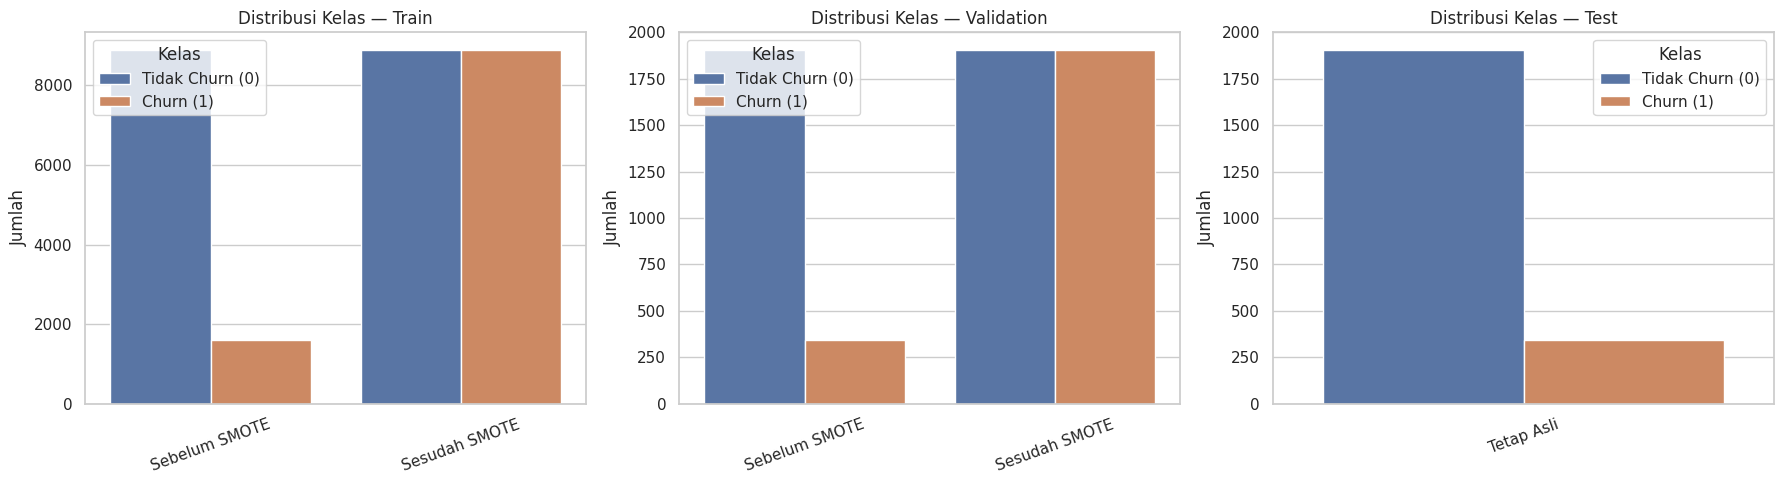

Train setelah SMOTE:


,count
churn,
0,8892
1,8892



Validation setelah SMOTE:


,count
churn,
0,1905
1,1905



Test tetap asli:


,count
churn,
0,1905
1,345


In [25]:
# ============================================================
# SMOTE HANYA PADA TRAIN DAN VALIDATION
# ============================================================

X_train_smote_df, y_train_smote = apply_smote_to_split(
    X_train_processed_df,
    y_train_prep.reset_index(drop=True)
)

X_val_smote_df, y_val_smote = apply_smote_to_split(
    X_val_processed_df,
    y_val_prep.reset_index(drop=True)
)

# Test tetap tidak di-SMOTE.
X_test_original_df = X_test_processed_df.copy()
y_test_original = y_test_prep.reset_index(drop=True).copy()

distribution_records = []

for split_name, split_target, status in [
    ("Train", y_train_prep.reset_index(drop=True), "Sebelum SMOTE"),
    ("Train", y_train_smote, "Sesudah SMOTE"),
    ("Validation", y_val_prep.reset_index(drop=True), "Sebelum SMOTE"),
    ("Validation", y_val_smote, "Sesudah SMOTE"),
    ("Test", y_test_original, "Tetap Asli")
]:
    counts = split_target.value_counts().sort_index()

    for class_value, count in counts.items():
        distribution_records.append({
            "Split": split_name,
            "Status": status,
            "Kelas": (
                "Tidak Churn (0)"
                if class_value == 0
                else "Churn (1)"
            ),
            "Jumlah": int(count)
        })

balance_comparison_df = pd.DataFrame(distribution_records)

display(balance_comparison_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, split_name in zip(
    axes,
    ["Train", "Validation", "Test"]
):
    split_data = balance_comparison_df[
        balance_comparison_df["Split"] == split_name
    ]

    sns.barplot(
        data=split_data,
        x="Status",
        y="Jumlah",
        hue="Kelas",
        ax=axis
    )

    axis.set_title(f"Distribusi Kelas — {split_name}")
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print("Train setelah SMOTE:")
display(y_train_smote.value_counts().sort_index())

print("\nValidation setelah SMOTE:")
display(y_val_smote.value_counts().sort_index())

print("\nTest tetap asli:")
display(y_test_original.value_counts().sort_index())

In [26]:
# ============================================================
# DATA FINAL UNTUK MODELING
# ============================================================

X_train_final = X_train_smote_df.copy()
y_train_final = y_train_smote.copy()

X_val_final = X_val_smote_df.copy()
y_val_final = y_val_smote.copy()

X_test_final = X_test_original_df.copy()
y_test_final = y_test_original.copy()

print("Data final:")
print("Train setelah SMOTE     :", X_train_final.shape)
print("Validation setelah SMOTE:", X_val_final.shape)
print("Test asli               :", X_test_final.shape)

Data final:
Train setelah SMOTE     : (17784, 49)
Validation setelah SMOTE: (3810, 49)
Test asli               : (2250, 49)


## 2.2.2 Melatih Tiga Model dengan Preprocessing dan SMOTE

Preprocessing + SMOTE — Logistic Regression
Dataset evaluasi: Validation setelah SMOTE
Accuracy : 0.7575
Precision: 0.7535
Recall   : 0.7654
F1-Score : 0.7594

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.75      0.76      1905
           1       0.75      0.77      0.76      1905

    accuracy                           0.76      3810
   macro avg       0.76      0.76      0.76      3810
weighted avg       0.76      0.76      0.76      3810



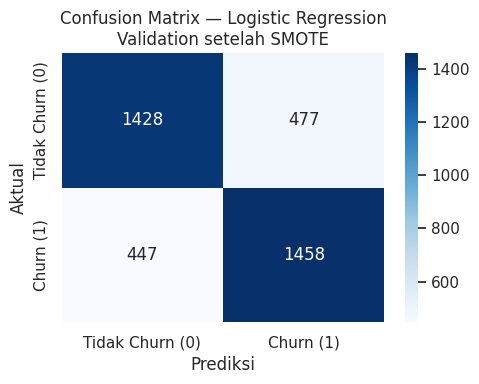

Preprocessing + SMOTE — Random Forest
Dataset evaluasi: Validation setelah SMOTE
Accuracy : 0.9089
Precision: 0.9091
Recall   : 0.9087
F1-Score : 0.9089

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1905
           1       0.91      0.91      0.91      1905

    accuracy                           0.91      3810
   macro avg       0.91      0.91      0.91      3810
weighted avg       0.91      0.91      0.91      3810



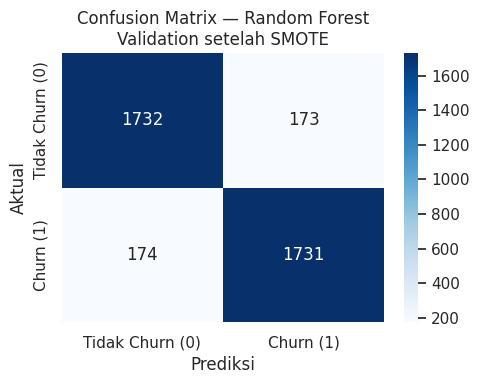

Preprocessing + SMOTE — Voting Classifier
Dataset evaluasi: Validation setelah SMOTE
Accuracy : 0.8218
Precision: 0.7791
Recall   : 0.8982
F1-Score : 0.8344

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1905
           1       0.78      0.90      0.83      1905

    accuracy                           0.82      3810
   macro avg       0.83      0.82      0.82      3810
weighted avg       0.83      0.82      0.82      3810



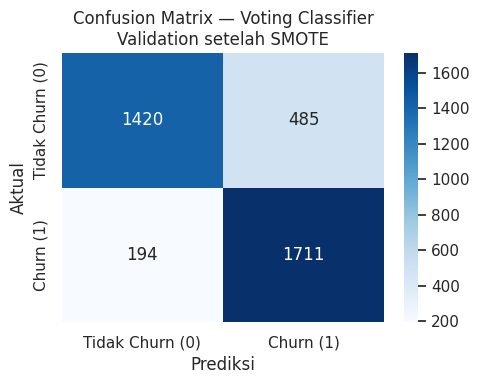

In [27]:
# ============================================================
# TIGA MODEL PREPROCESSING + SMOTE
# ============================================================

preprocessing_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Voting Classifier": VotingClassifier(
        estimators=[
            (
                "lr",
                LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE
                )
            ),
            (
                "knn",
                KNeighborsClassifier(n_neighbors=5)
            ),
            (
                "nb",
                GaussianNB()
            )
        ],
        voting="soft"
    )
}

for model_name, model in preprocessing_models.items():
    model.fit(
        X_train_final,
        y_train_final
    )

    preprocessing_prediction = model.predict(
        X_val_final
    )

    evaluate_classification_model(
        model_name=model_name,
        scenario_name="Preprocessing + SMOTE",
        dataset_name="Validation setelah SMOTE",
        y_true=y_val_final,
        y_pred=preprocessing_prediction
    )

In [28]:
# ============================================================
# RINGKASAN HASIL PREPROCESSING + SMOTE
# ============================================================

all_development_results_df = pd.DataFrame(
    evaluation_results
)

preprocessing_results_df = all_development_results_df[
    all_development_results_df["Skenario"]
    == "Preprocessing + SMOTE"
].sort_values(
    by="F1-Score",
    ascending=False
)

display(preprocessing_results_df)

,Skenario,Dataset Evaluasi,Model,Accuracy,Precision,Recall,F1-Score
4,Preprocessing + SMOTE,Validation setelah SMOTE,Random Forest,0.908924,0.909139,0.908661,0.908900
5,Preprocessing + SMOTE,Validation setelah SMOTE,Voting Classifier,0.821785,0.779144,0.898163,0.834431
3,Preprocessing + SMOTE,Validation setelah SMOTE,Logistic Regression,0.757480,0.753488,0.765354,0.759375


# Perbandingan Direct Modeling dan Preprocessing + SMOTE

,Skenario,Dataset Evaluasi,Model,Accuracy,Precision,Recall,F1-Score
4,Preprocessing + SMOTE,Validation setelah SMOTE,Random Forest,0.908924,0.909139,0.908661,0.908900
1,Direct Modeling + SMOTE,Validation setelah SMOTE,Random Forest,0.879265,0.862155,0.902887,0.882051
5,Preprocessing + SMOTE,Validation setelah SMOTE,Voting Classifier,0.821785,0.779144,0.898163,0.834431
2,Direct Modeling + SMOTE,Validation setelah SMOTE,Voting Classifier,0.778215,0.764207,0.804724,0.783943
0,Direct Modeling + SMOTE,Validation setelah SMOTE,Logistic Regression,0.761155,0.749874,0.783727,0.766427
3,Preprocessing + SMOTE,Validation setelah SMOTE,Logistic Regression,0.757480,0.753488,0.765354,0.759375


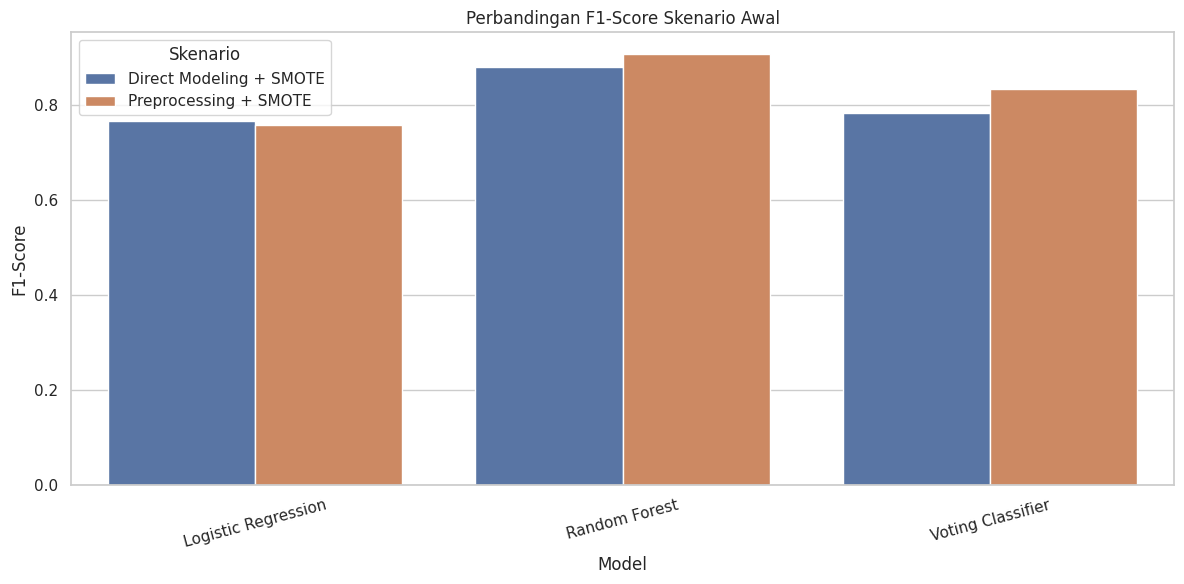

In [29]:
# ============================================================
# PERBANDINGAN DUA SKENARIO AWAL
# ============================================================

development_comparison_df = pd.DataFrame(
    evaluation_results
)

display(
    development_comparison_df.sort_values(
        by=["F1-Score", "Recall"],
        ascending=False
    )
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=development_comparison_df,
    x="Model",
    y="F1-Score",
    hue="Skenario"
)
plt.title("Perbandingan F1-Score Skenario Awal")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Poin Penugasan 3 — Feature Importance dan Hyperparameter Tuning

## 3.1 Analisis Feature Importance Setelah Preprocessing dan SMOTE

,Fitur,Importance
9,satisfaction_score,0.213578
17,total_spent,0.182209
7,support_tickets,0.073346
23,country_Germany,0.025808
35,acquisition_channel_Facebook Ads,0.017764
39,device_type_Desktop,0.017372
11,marketing_spend_per_user,0.015923
12,lifetime_value,0.015070
6,email_click_rate,0.014850
16,days_since_last_purchase,0.014812


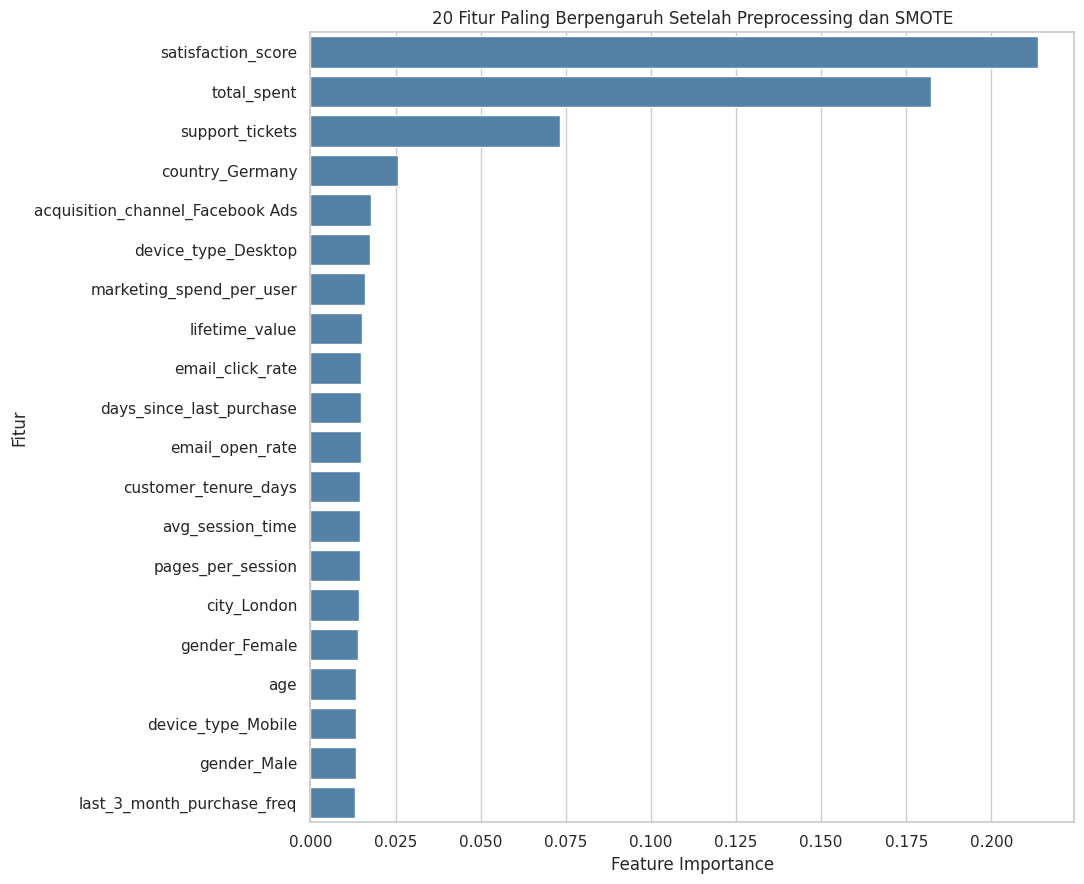

In [30]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feature_importance_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_importance_model.fit(
    X_train_final,
    y_train_final
)

importance_df = pd.DataFrame({
    "Fitur": X_train_final.columns,
    "Importance": feature_importance_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(importance_df.head(25))

plt.figure(figsize=(11, 9))
sns.barplot(
    data=importance_df.head(20),
    x="Importance",
    y="Fitur",
    color="steelblue"
)
plt.title("20 Fitur Paling Berpengaruh Setelah Preprocessing dan SMOTE")
plt.xlabel("Feature Importance")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

## 3.2 Hyperparameter Tuning

Semua model tuning dilatih pada **train hasil SMOTE** dan dipilih menggunakan **validation hasil SMOTE**. Tidak ada penggunaan `class_weight` karena imbalance sudah ditangani dengan SMOTE.

In [31]:
# ============================================================
# KONFIGURASI CROSS VALIDATION
# ============================================================

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

tuning_results = []

def evaluate_tuned_model(model_name, model):
    prediction = model.predict(X_val_final)

    result = evaluate_classification_model(
        model_name=model_name,
        scenario_name="Hyperparameter Tuning + SMOTE",
        dataset_name="Validation setelah SMOTE",
        y_true=y_val_final,
        y_pred=prediction,
        save_result=False
    )

    tuning_results.append(result)

    return result

### 3.2.1 Logistic Regression

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Parameter terbaik Logistic Regression:
{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1: 0.7809926577036124
Hyperparameter Tuning + SMOTE — Logistic Regression - Tuning
Dataset evaluasi: Validation setelah SMOTE
Accuracy : 0.7585
Precision: 0.7532
Recall   : 0.769
F1-Score : 0.761

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.75      0.76      1905
           1       0.75      0.77      0.76      1905

    accuracy                           0.76      3810
   macro avg       0.76      0.76      0.76      3810
weighted avg       0.76      0.76      0.76      3810



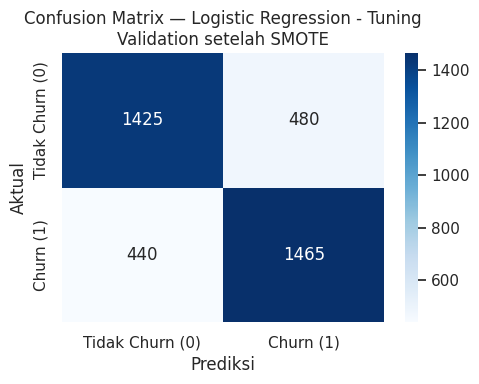

In [32]:
# ============================================================
# TUNING LOGISTIC REGRESSION
# ============================================================

logreg_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ),
    param_grid={
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "lbfgs"],
        "penalty": ["l2"]
    },
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

logreg_search.fit(
    X_train_final,
    y_train_final
)

best_logreg = logreg_search.best_estimator_

print("Parameter terbaik Logistic Regression:")
print(logreg_search.best_params_)
print("Best CV F1:", logreg_search.best_score_)

logreg_tuning_eval = evaluate_tuned_model(
    "Logistic Regression - Tuning",
    best_logreg
)

### 3.2.2 Random Forest

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Parameter terbaik Random Forest:
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
Best CV F1: 0.9345726687366925
Hyperparameter Tuning + SMOTE — Random Forest - Tuning
Dataset evaluasi: Validation setelah SMOTE
Accuracy : 0.906
Precision: 0.9215
Recall   : 0.8877
F1-Score : 0.9043

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91      1905
           1       0.92      0.89      0.90      1905

    accuracy                           0.91      3810
   macro avg       0.91      0.91      0.91      3810
weighted avg       0.91      0.91      0.91      3810



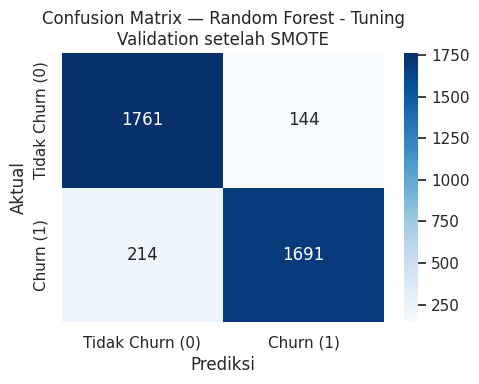

In [33]:
# ============================================================
# TUNING RANDOM FOREST
# ============================================================

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions={
        "n_estimators": [100, 200, 300, 400],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    },
    n_iter=15,
    scoring="f1",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(
    X_train_final,
    y_train_final
)

best_rf = rf_search.best_estimator_

print("Parameter terbaik Random Forest:")
print(rf_search.best_params_)
print("Best CV F1:", rf_search.best_score_)

rf_tuning_eval = evaluate_tuned_model(
    "Random Forest - Tuning",
    best_rf
)

### 3.2.3 Voting Classifier

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Parameter terbaik Voting Classifier:
{'weights': [1, 1, 2], 'nb__var_smoothing': np.float64(1e-10), 'lr__C': 0.01, 'knn__n_neighbors': 3}
Best CV F1: 0.878950754238907
Hyperparameter Tuning + SMOTE — Voting Classifier - Tuning
Dataset evaluasi: Validation setelah SMOTE
Accuracy : 0.8352
Precision: 0.8056
Recall   : 0.8835
F1-Score : 0.8428

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1905
           1       0.81      0.88      0.84      1905

    accuracy                           0.84      3810
   macro avg       0.84      0.84      0.83      3810
weighted avg       0.84      0.84      0.83      3810



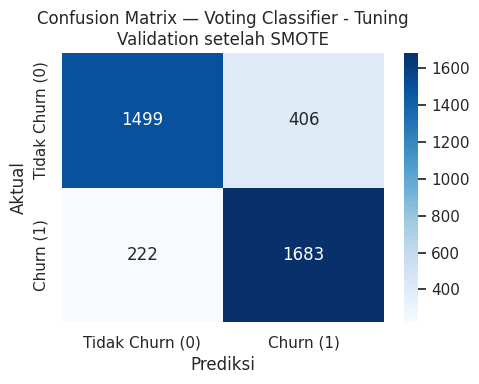

In [34]:
# ============================================================
# TUNING VOTING CLASSIFIER
# ============================================================

voting_model = VotingClassifier(
    estimators=[
        (
            "lr",
            LogisticRegression(
                max_iter=3000,
                random_state=RANDOM_STATE
            )
        ),
        (
            "knn",
            KNeighborsClassifier()
        ),
        (
            "nb",
            GaussianNB()
        )
    ],
    voting="soft"
)

voting_search = RandomizedSearchCV(
    estimator=voting_model,
    param_distributions={
        "weights": [
            [1, 1, 1],
            [2, 1, 1],
            [1, 2, 1],
            [1, 1, 2],
            [2, 2, 1],
            [2, 1, 2]
        ],
        "lr__C": [0.01, 0.1, 1, 10],
        "knn__n_neighbors": [3, 5, 7, 9],
        "nb__var_smoothing": np.logspace(-11, -7, 5)
    },
    n_iter=12,
    scoring="f1",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

voting_search.fit(
    X_train_final,
    y_train_final
)

best_voting = voting_search.best_estimator_

print("Parameter terbaik Voting Classifier:")
print(voting_search.best_params_)
print("Best CV F1:", voting_search.best_score_)

voting_tuning_eval = evaluate_tuned_model(
    "Voting Classifier - Tuning",
    best_voting
)

## 3.3 Ringkasan dan Pemilihan Model Terbaik Berdasarkan Validation

In [35]:
# ============================================================
# RINGKASAN HASIL TUNING
# ============================================================

tuning_results_df = (
    pd.DataFrame(tuning_results)
    .sort_values(
        by=["F1-Score", "Recall"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(tuning_results_df)

model_lookup = {
    "Logistic Regression - Tuning": best_logreg,
    "Random Forest - Tuning": best_rf,
    "Voting Classifier - Tuning": best_voting
}

best_tuning_row = tuning_results_df.iloc[0]
best_tuning_model_name = best_tuning_row["Model"]
best_tuning_model = model_lookup[best_tuning_model_name]

print("Model terbaik berdasarkan validation:")
print(best_tuning_model_name)

print("\nDetail performa validation:")
display(best_tuning_row)

,Skenario,Dataset Evaluasi,Model,Accuracy,Precision,Recall,F1-Score
0,Hyperparameter Tuning + SMOTE,Validation setelah SMOTE,Random Forest - Tuning,0.906037,0.921526,0.887664,0.904278
1,Hyperparameter Tuning + SMOTE,Validation setelah SMOTE,Voting Classifier - Tuning,0.835171,0.805649,0.883465,0.842764
2,Hyperparameter Tuning + SMOTE,Validation setelah SMOTE,Logistic Regression - Tuning,0.758530,0.753213,0.769029,0.761039


Model terbaik berdasarkan validation:
Random Forest - Tuning

Detail performa validation:


,0
Skenario,Hyperparameter Tuning + SMOTE
Dataset Evaluasi,Validation setelah SMOTE
Model,Random Forest - Tuning
Accuracy,0.906037
Precision,0.921526
Recall,0.887664
F1-Score,0.904278


## 3.4 Pelatihan Ulang dan Evaluasi Akhir pada Test Asli

Setelah model terbaik dipilih menggunakan validation hasil SMOTE, model dilatih ulang memakai gabungan train dan validation yang sudah diseimbangkan. Evaluasi akhir hanya dilakukan pada test asli yang tidak pernah terkena SMOTE.

Evaluasi Akhir — Random Forest - Tuning
Dataset evaluasi: Test asli tanpa SMOTE
Accuracy : 0.8529
Precision: 0.5276
Recall   : 0.3884
F1-Score : 0.4474

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      1905
           1       0.53      0.39      0.45       345

    accuracy                           0.85      2250
   macro avg       0.71      0.66      0.68      2250
weighted avg       0.84      0.85      0.84      2250



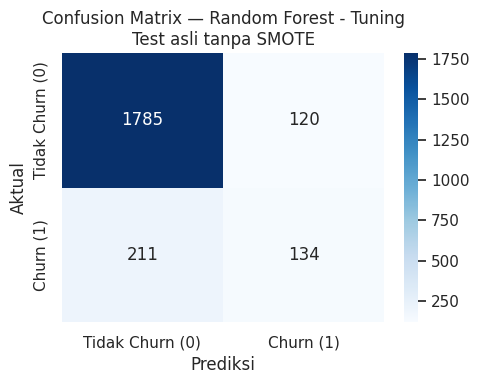

Hasil ini menjadi evaluasi akhir karena test tidak diseimbangkan.


In [36]:
# ============================================================
# RETRAIN MODEL TERBAIK DENGAN TRAIN + VALIDATION SMOTE
# ============================================================

X_train_val_final = pd.concat(
    [X_train_final, X_val_final],
    ignore_index=True
)

y_train_val_final = pd.concat(
    [y_train_final, y_val_final],
    ignore_index=True
)

best_tuning_model.fit(
    X_train_val_final,
    y_train_val_final
)

final_test_prediction = best_tuning_model.predict(
    X_test_final
)

final_test_result = evaluate_classification_model(
    model_name=best_tuning_model_name,
    scenario_name="Evaluasi Akhir",
    dataset_name="Test asli tanpa SMOTE",
    y_true=y_test_final,
    y_pred=final_test_prediction,
    save_result=False
)

print("Hasil ini menjadi evaluasi akhir karena test tidak diseimbangkan.")

## 3.5 Perbandingan Sembilan Model

,Skenario,Dataset Evaluasi,Model,Accuracy,Precision,Recall,F1-Score
4,Preprocessing + SMOTE,Validation setelah SMOTE,Random Forest,0.908924,0.909139,0.908661,0.908900
7,Hyperparameter Tuning + SMOTE,Validation setelah SMOTE,Random Forest - Tuning,0.906037,0.921526,0.887664,0.904278
1,Direct Modeling + SMOTE,Validation setelah SMOTE,Random Forest,0.879265,0.862155,0.902887,0.882051
8,Hyperparameter Tuning + SMOTE,Validation setelah SMOTE,Voting Classifier - Tuning,0.835171,0.805649,0.883465,0.842764
5,Preprocessing + SMOTE,Validation setelah SMOTE,Voting Classifier,0.821785,0.779144,0.898163,0.834431
2,Direct Modeling + SMOTE,Validation setelah SMOTE,Voting Classifier,0.778215,0.764207,0.804724,0.783943
0,Direct Modeling + SMOTE,Validation setelah SMOTE,Logistic Regression,0.761155,0.749874,0.783727,0.766427
6,Hyperparameter Tuning + SMOTE,Validation setelah SMOTE,Logistic Regression - Tuning,0.758530,0.753213,0.769029,0.761039
3,Preprocessing + SMOTE,Validation setelah SMOTE,Logistic Regression,0.757480,0.753488,0.765354,0.759375


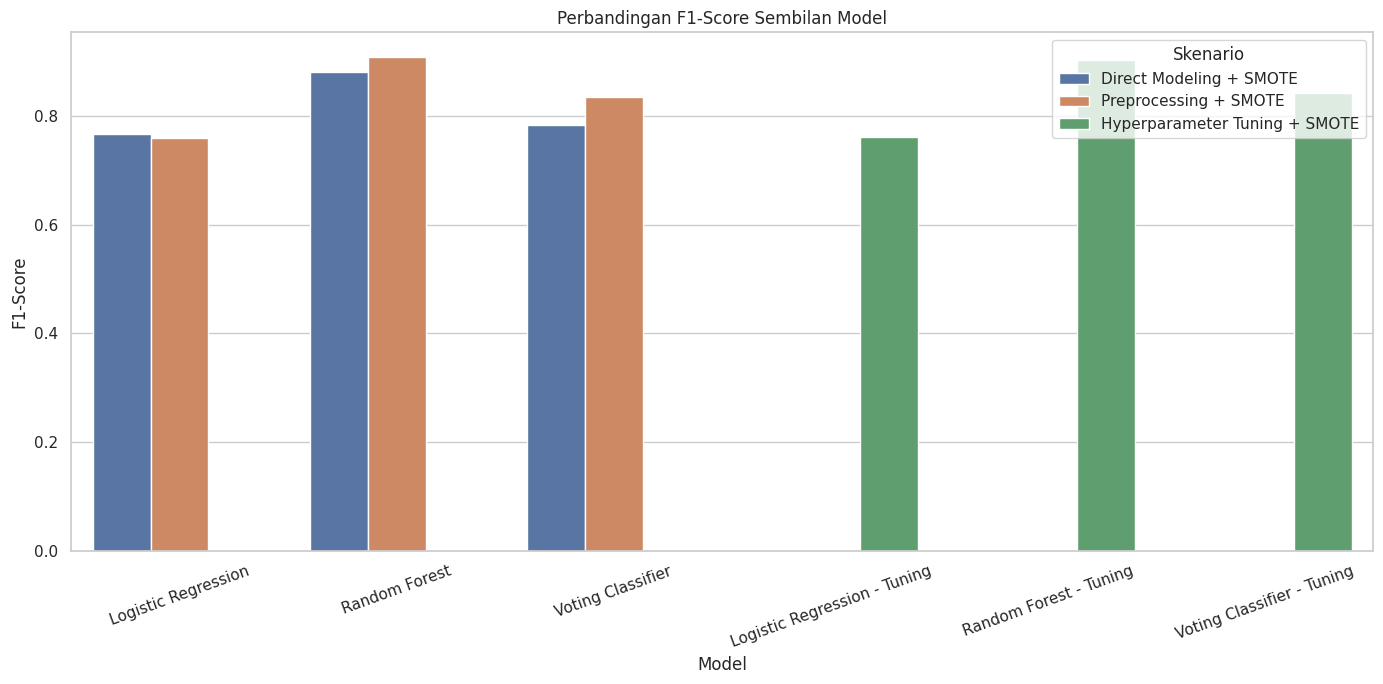

In [37]:
# ============================================================
# PERBANDINGAN SEMBILAN MODEL
# ============================================================

nine_model_results_df = pd.concat(
    [
        pd.DataFrame(evaluation_results),
        pd.DataFrame(tuning_results)
    ],
    ignore_index=True
)

if len(nine_model_results_df) != 9:
    raise ValueError(
        "Jumlah hasil model harus sembilan, "
        f"tetapi ditemukan {len(nine_model_results_df)}."
    )

display(
    nine_model_results_df.sort_values(
        by=["F1-Score", "Recall"],
        ascending=False
    )
)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=nine_model_results_df,
    x="Model",
    y="F1-Score",
    hue="Skenario"
)
plt.title("Perbandingan F1-Score Sembilan Model")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 3.6 Menyimpan Model dan Komponen Deployment

In [40]:
# ============================================================
# MENYIMPAN MODEL DAN KOMPONEN DEPLOYMENT
# ============================================================

drive_folder = "/content/drive/MyDrive/UAS-BengkelKoding"
os.makedirs(drive_folder, exist_ok=True)

model_filename = "customer_churn_deployment.joblib"
runtime_path = f"/content/{model_filename}"
drive_path = os.path.join(
    drive_folder,
    model_filename
)

deployment_artifact = {
    "model": best_tuning_model,
    "model_name": best_tuning_model_name,
    "preprocessor": preprocessor,
    "iqr_bounds": iqr_bounds,
    "input_feature_columns": X_prep.columns.tolist(),
    "processed_feature_columns": feature_names,
    "reference_date": reference_date,
    "target_column": TARGET_COLUMN,
    "dropped_low_impact_features": low_impact_features,
    "imputation_strategy": imputation_strategy_summary,
    "smote_information": {
        "method": "SMOTE",
        "applied_to": ["train", "validation"],
        "test_balanced": False,
        "random_state": RANDOM_STATE
    },
    "evaluation": {
        "dataset": "test asli tanpa SMOTE",
        "accuracy": float(final_test_result["Accuracy"]),
        "precision": float(final_test_result["Precision"]),
        "recall": float(final_test_result["Recall"]),
        "f1_score": float(final_test_result["F1-Score"])
    }
}

joblib.dump(
    deployment_artifact,
    runtime_path
)

joblib.dump(
    deployment_artifact,
    drive_path
)

print("Model dan komponen deployment berhasil disimpan.")
print("Model terbaik :", best_tuning_model_name)
print("Runtime       :", runtime_path)
print("Google Drive  :", drive_path)

print("\nKomponen yang disimpan:")
for key in deployment_artifact:
    print("-", key)

Model dan komponen deployment berhasil disimpan.
Model terbaik : Random Forest - Tuning
Runtime       : /content/customer_churn_deployment.joblib
Google Drive  : /content/drive/MyDrive/UAS-BengkelKoding/customer_churn_deployment.joblib

Komponen yang disimpan:
- model
- model_name
- preprocessor
- iqr_bounds
- input_feature_columns
- processed_feature_columns
- reference_date
- target_column
- dropped_low_impact_features
- imputation_strategy
- smote_information
- evaluation


In [41]:
# ============================================================
# DOWNLOAD FILE MODEL DARI COLAB
# ============================================================

files.download(runtime_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Kesimpulan

Berdasarkan seluruh proses yang telah dilakukan, project ini berhasil membangun sistem prediksi *customer churn* mulai dari tahap EDA, preprocessing, penanganan ketidakseimbangan kelas, modeling, hyperparameter tuning, evaluasi, sampai penyimpanan model untuk deployment.

## Hasil Pengolahan Data

Tahapan pengolahan data yang telah dilakukan meliputi:

* Pemeriksaan struktur, tipe data, statistik deskriptif, dan distribusi target.
* Visualisasi missing value dan outlier pada tahap EDA.
* Encoding fitur kategorikal agar pengaruh setiap kategori terhadap target dapat dianalisis.
* Pengubahan `coupon_code` menjadi `has_coupon_code`.
* Pengubahan kolom tanggal menjadi:

  * `customer_tenure_days`
  * `days_since_last_purchase`
* Penghapusan tiga fitur dengan pengaruh terendah, yaitu:

  * `customer_id`
  * `discount_used`
  * `avg_order_value`
* Penanganan outlier menggunakan **IQR capping**.
* Pengisian missing value numerik menggunakan **mean atau median** sesuai distribusi fitur.
* Pengisian missing value kategorikal menggunakan **modus**.
* Pengubahan fitur kategorikal menggunakan **OneHotEncoder**.
* Scaling fitur numerik menggunakan **StandardScaler**.
* Penanganan ketidakseimbangan kelas menggunakan **SMOTE**.

SMOTE hanya diterapkan pada data train dan validation. Data test tetap menggunakan distribusi asli agar evaluasi akhir dapat menggambarkan performa model pada kondisi data sebenarnya.

---

## Hasil Eksperimen

Tiga model yang digunakan adalah Logistic Regression, Random Forest, dan Voting Classifier. Ketiga model tersebut diuji pada tiga skenario sehingga menghasilkan sembilan hasil eksperimen.

Hasil perbandingan menunjukkan bahwa performa validation tertinggi diperoleh oleh:

### Random Forest — Preprocessing + SMOTE

* **Accuracy:** 0.9089
* **Precision:** 0.9091
* **Recall:** 0.9087
* **F1-Score:** 0.9089

Pada tahap hyperparameter tuning, model terbaik yang diperoleh adalah:

### Random Forest — Hyperparameter Tuning + SMOTE

Parameter terbaik:

* `n_estimators = 400`
* `min_samples_split = 2`
* `min_samples_leaf = 2`
* `max_features = "log2"`
* `max_depth = 20`

Hasil validation setelah tuning:

* **Accuracy:** 0.9060
* **Precision:** 0.9215
* **Recall:** 0.8877
* **F1-Score:** 0.9043

---

## Evaluasi Akhir pada Data Test

Model yang dipilih kemudian dilatih ulang menggunakan data train dan validation, lalu dievaluasi menggunakan data test asli tanpa SMOTE.

Hasil evaluasi akhir:

* **Accuracy:** 0.8529
* **Precision:** 0.5276
* **Recall:** 0.3884
* **F1-Score:** 0.4474

Hasil tersebut menunjukkan bahwa performa model pada data validation yang telah diseimbangkan lebih tinggi dibandingkan pada data test dengan distribusi asli. Hal ini menunjukkan bahwa ketidakseimbangan kelas tetap menjadi tantangan ketika model diterapkan pada kondisi data sebenarnya.

---

## Hasil Akhir Project

Model terbaik beserta seluruh komponen preprocessing berhasil disimpan ke dalam file:

```text
customer_churn_deployment.joblib
```

File tersebut berisi:

* Model klasifikasi.
* Preprocessor.
* Batas IQR.
* Daftar dan urutan fitur.
* Strategi imputasi.
* Informasi SMOTE.
* Tanggal referensi.
* Fitur yang dihapus.
* Hasil evaluasi model.

File `customer_churn_deployment.joblib` kemudian dipanggil oleh aplikasi Streamlit melalui file `app.py`.

Aplikasi dapat menerima data pelanggan, menjalankan preprocessing yang sama seperti saat training, kemudian menampilkan:

* Prediksi churn atau tidak churn.
* Probabilitas churn.
* Model yang digunakan.
* Hasil evaluasi model.
* Data hasil feature engineering.
* Hasil prediksi dalam format CSV.

Dengan demikian, project ini telah menyelesaikan seluruh proses mulai dari analisis data, pembangunan dan perbandingan model, sampai penerapan model ke dalam aplikasi prediksi berbasis Streamlit.
